BLOC 1
Analyse de la détection de fraude via les graphes

BLOC 2
Sommaire:
- Configuration & Collecte de Données : Importation des bibliothèques (Torch, Sklearn, Pandas), blocage des graines aléatoires (seeds) pour la reproductibilité scientifique et chargement du jeu de données.
 Pipeline de Prétraitement : Ingénierie des caractéristiques (feature engineering), mise à l'échelle robuste des données (StandardScaler) et fractionnement stratifié entre Entraînement et Validation.
Définition de l'Architecture (Réseau Cible) : Structuration du réseau de neurones profonds (FraudDetectionANN) avec intégration de hooks personnalisés pour extraire les activations des couches cachées.
Entraînement & Sérialisation du Modèle : Entraînement du réseau en appliquant des poids pour gérer le déséquilibre des classes (pos_weight), évaluation du Rappel (Recall) / F1-score, et sauvegarde des poids entraînés sur le disque (.pth).
Génération d'Attaques Adversariales (Logit PGD) : Exécution d'une boucle de Descente de Gradient Projetée (Projected Gradient Descent) ciblant les sorties brutes (logits) pour aveugler le réseau, validée par le Taux de Succès de l'Attaque (ASR).
Isolation Topologique (Nœuds Critiques) : Calcul de la déviation latente absolue moyenne à travers le réseau pour filtrer et extraire uniquement les neurones les plus fortement perturbés.
Moteur de Réseau Géométrique (Graphes SOTA) : Génération de matrices de similarité RBF (noyau de fonction à base radiale), application d'un filtre strict Mutual $k$-NN, et calcul de la centralité des nœuds via l'algorithme PageRank.
Détection d'Anomalies (Recherche sur Grille 4D) : Extraction de signatures statistiques de graphes en 12 dimensions et entraînement de modèles One-Class SVM / Isolation Forest pour intercepter 100 % des fraudes ayant contourné le réseau initial.

In [ ]:
# BLOC 3
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
# NOUVEAU IMPORT : Importation de SMOTE
from imblearn.over_sampling import SMOTE 

# ==========================================
# ÉTAPE 1 : Configuration et Chargement
# ==========================================
file_path = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_Adversarial_Attack_Detection\Fraude Detection\creditcard.csv" 
batch_size = 256

print("Chargement des données en cours...")
df = pd.read_csv(file_path)
print(f"Dataset chargé : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

# ==========================================
# ÉTAPE 2 : Prétraitement
# ==========================================
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

if 'Amount' in df.columns:
    scaler = RobustScaler()
    df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
    
X = df.drop('Class', axis=1).values
y = df['Class'].values

# ==========================================
# ÉTAPE 3 : Séparation (Entraînement / Validation)
# ==========================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Avant SMOTE ---")
print(f"Fraudes dans l'entraînement : {sum(y_train)} / {len(y_train)}")
print(f"Fraudes dans la validation  : {sum(y_val)} / {len(y_val)}")

# ==========================================
# ÉTAPE 3.5 : Application de SMOTE (NOUVEAU)
# ==========================================
print("\n🔄 Application de SMOTE sur le set d'entraînement uniquement...")
smote = SMOTE(random_state=42)

# SMOTE va écraser X_train et y_train en y ajoutant les fraudes synthétiques
X_train, y_train = smote.fit_resample(X_train, y_train)

print("--- Après SMOTE ---")
print(f"Fraudes dans l'entraînement : {sum(y_train)} / {len(y_train)} (Équilibre parfait 50/50 !)")
print(f"Fraudes dans la validation  : {sum(y_val)} / {len(y_val)} (Le set de validation reste intact)")

# ==========================================
# ÉTAPE 4 : Création des Tenseurs
# ==========================================
# Les variables X_train et y_train contiennent maintenant les données équilibrées par SMOTE
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

# ==========================================
# ÉTAPE 5 : Création des DataLoaders (Pour l'entraînement normal)
# ==========================================
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

input_dimension = X_train.shape[1] 
print(f"\nDimension d'entrée pour le ANN : {input_dimension}")

# ==========================================
# ÉTAPE 6 : EXTRACTION POUR LE TEST DES NOEUDS CRITIQUES
# ==========================================
print("\n--- Préparation du Set pour l'Analyse des Nœuds Critiques ---")

# 1. On cherche les indices de TOUTES les fraudes dans le set de validation (qui est resté réel et intact)
indices_fraudes = np.where(y_val == 1)[0]

# 2. On choisit combien de fraudes on veut garder pour notre test futur
nombre_a_tester = 200
nombre_a_tester = min(nombre_a_tester, len(indices_fraudes))

# 3. On extrait ces lignes spécifiques
indices_selectionnes = indices_fraudes[:nombre_a_tester]
X_test_critique = X_val_tensor[indices_selectionnes]
y_test_critique = y_val_tensor[indices_selectionnes]

print(f"Nous avons isolé {X_test_critique.shape[0]} transactions frauduleuses réelles.")
print("La variable 'X_test_critique' est prête pour l'étape de l'attaque et l'extraction du graphe !")

Chargement des données en cours...
Dataset chargé : 284807 lignes et 31 colonnes.

--- Avant SMOTE ---
Fraudes dans l'entraînement : 394 / 227845
Fraudes dans la validation  : 98 / 56962

🔄 Application de SMOTE sur le set d'entraînement uniquement...
--- Après SMOTE ---
Fraudes dans l'entraînement : 227451 / 454902 (Équilibre parfait 50/50 !)
Fraudes dans la validation  : 98 / 56962 (Le set de validation reste intact)

Dimension d'entrée pour le ANN : 29

--- Préparation du Set pour l'Analyse des Nœuds Critiques ---
Nous avons isolé 98 transactions frauduleuses réelles.
La variable 'X_test_critique' est prête pour l'étape de l'attaque et l'extraction du graphe !


In [ ]:
# BLOC 4
#creation of the ANN model
#Here is the architecture of the ANN model,
#3 layers 128, 64, 32 + batch normalization and dropout of 20%
import torch
import torch.nn as nn

class FraudDetectionANN(nn.Module):
    def __init__(self, input_dim=29): # 29 car on a supprimé 'Time'
        super(FraudDetectionANN, self).__init__()
        
        self.layer1 = nn.Linear(input_dim, 128)
        self.layer2 = nn.Linear(128, 64)
        self.penultimate_layer = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)

    def forward(self, x, extract_all_activations=False):
        # Couche 1
        x1 = self.layer1(x)
        x1 = self.bn1(x1)
        a1 = self.relu(x1)
        x_drop1 = self.dropout(a1)
        
        # Couche 2
        x2 = self.layer2(x_drop1)
        x2 = self.bn2(x2)
        a2 = self.relu(x2)
        x_drop2 = self.dropout(a2)
        
        # Couche 3 (Graphe)
        x3 = self.penultimate_layer(x_drop2)
        a3 = self.relu(x3)
        
        # --- LA MODIFICATION EST ICI ---
        if extract_all_activations:
            # On renvoie un dictionnaire avec l'état exact de chaque couche
            return {"layer1_128": a1, "layer2_64": a2, "layer3_32": a3}
            
        out = self.output_layer(a3)
        return out

In [ ]:
# BLOC 5
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score # <--- AJOUT CRITIQUE

# ==========================================
# 1. PRÉPARATION ET CONFIGURATION
# ==========================================
epochs = 10  # Nombre de fois que le réseau va voir l'intégralité du dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciation de ton modèle (Assure-toi d'avoir exécuté la cellule de la classe 'FraudDetectionANN' juste avant !)
model = FraudDetectionANN(input_dim=input_dimension).to(device)

# Le chemin exact où le modèle doit être sauvegardé/chargé
chemin_sauvegarde = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\fraud_ann_model.pth"

# ==========================================
# 2. LOGIQUE DE CHARGEMENT OU D'ENTRAÎNEMENT
# ==========================================
if os.path.exists(chemin_sauvegarde):
    # --- LE MODÈLE EXISTE DÉJÀ : ON LE CHARGE ---
    print(f"🔄 Modèle existant trouvé à l'emplacement : {chemin_sauvegarde}")
    print("Chargement des poids en cours...")
    
    # Chargement des poids dans l'architecture
    model.load_state_dict(torch.load(chemin_sauvegarde, map_location=device))
    
    # Très important : on met le modèle en mode évaluation (désactive le Dropout)
    model.eval()
    print("✅ Modèle chargé avec succès ! Prêt pour les tests.")

else:
    # --- LE MODÈLE N'EXISTE PAS : ON LANCE L'ENTRAÎNEMENT ---
    print(f"❌ Aucun modèle trouvé à l'emplacement : {chemin_sauvegarde}")
    print(f"🚀 Lancement d'un nouvel entraînement sur : {device}")

    # MODIFICATION SMOTE : Plus besoin de pos_weight car le dataset d'entraînement est à 50/50 !
    criterion = nn.BCEWithLogitsLoss()

    # L'optimiseur (celui qui modifie les poids du réseau)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Début de l'entraînement...\n" + "="*60)

    for epoch in range(epochs):
        
        # --- A. PHASE D'ENTRAÎNEMENT ---
        model.train() # Active le mode apprentissage (Dropout, etc.)
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()               # 1. Efface les erreurs du calcul précédent
            outputs = model(X_batch)            # 2. Fait une prédiction
            loss = criterion(outputs, y_batch)  # 3. Calcule l'erreur
            
            loss.backward()                     # 4. Calcule comment corriger les poids
            optimizer.step()                    # 5. Applique la correction
            
            train_loss += loss.item()
            
        train_loss /= len(train_loader)
        
        # --- B. PHASE DE VALIDATION ---
        model.eval() # Fige le réseau (il n'apprend plus)
        val_loss = 0.0
        
        all_preds = []
        all_probs = []   # <--- NOUVEAU : Stockage des probabilités continues pour le ROC AUC
        all_targets = []
        
        with torch.no_grad(): # Désactive le suivi de l'erreur pour économiser la mémoire
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                # Transformation des valeurs brutes en probabilités (0 à 1)
                probs = torch.sigmoid(outputs)
                # Décision : Si probabilité > 50%, c'est une fraude (1)
                preds = (probs > 0.5).float()
                
                all_probs.extend(probs.cpu().numpy())   # <--- NOUVEAU
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
                
        val_loss /= len(val_loader)
        
        # --- C. CALCUL DES MÉTRIQUES DE PERFORMANCE ---
        all_targets = np.array(all_targets)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)     # <--- NOUVEAU
        
        # Combien de fraudes ont été correctement repérées ?
        TP = np.sum((all_preds == 1) & (all_targets == 1))
        total_frauds = np.sum(all_targets == 1) 
        
        recall = recall_score(all_targets, all_preds, zero_division=0)
        precision = precision_score(all_targets, all_preds, zero_division=0)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        epoch_auc = roc_auc_score(all_targets, all_probs) # <--- NOUVEAU : Calcul du ROC AUC de validation
        
        # Affichage mis à jour
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  -> FRAUDES DÉTECTÉES : {int(TP)} / {int(total_frauds)} (Rappel: {recall:.2f})")
        print(f"  -> Précision: {precision:.2f} | F1-Score: {f1:.2f} | ROC AUC: {epoch_auc:.4f}") # <--- AJOUT
        print("-" * 60)

    print("🎉 Entraînement terminé !")

    # ==========================================
    # 3. SAUVEGARDE DU MODÈLE
    # ==========================================
    torch.save(model.state_dict(), chemin_sauvegarde)
    print(f"💾 Modèle sauvegardé avec succès sous : {chemin_sauvegarde}")

❌ Aucun modèle trouvé à l'emplacement : C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\fraud_ann_model.pth
🚀 Lancement d'un nouvel entraînement sur : cuda
Début de l'entraînement...
Epoch [1/10] | Train Loss: 0.0589 | Val Loss: 0.0260
  -> FRAUDES DÉTECTÉES : 87 / 98 (Rappel: 0.89)
  -> Précision: 0.14 | F1-Score: 0.25 | ROC AUC: 0.9736
------------------------------------------------------------
Epoch [2/10] | Train Loss: 0.0184 | Val Loss: 0.0150
  -> FRAUDES DÉTECTÉES : 85 / 98 (Rappel: 0.87)
  -> Précision: 0.26 | F1-Score: 0.40 | ROC AUC: 0.9767
------------------------------------------------------------
Epoch [3/10] | Train Loss: 0.0136 | Val Loss: 0.0144
  -> FRAUDES DÉTECTÉES : 86 / 98 (Rappel: 0.88)
  -> Précision: 0.27 | F1-Score: 0.41 | ROC AUC: 0.9784
------------------------------------------------------------
Epoch [4/10] | Train Loss: 0.0108 | Val Loss: 0.0118
  -> FRAUDES DÉTECTÉES : 86 / 98 (Rappel: 0.88)
  -> Précision: 0.34 | F1-Score: 0.49 | ROC AUC: 0

In [ ]:
# BLOC 6
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

print("==================================================================")
print(" 🔬 AUDIT STATISTIQUE EXHAUSTIF DU RÉSEAU DE NEURONES (ANN CIBLE) ")
print("==================================================================")

# 1. Passage impératif du modèle en mode évaluation (Désactivation du Dropout et du BatchNorm)
model.eval()

all_predictions_binaires = []
all_probabilites_continues = []
all_verites_terrain = []

# 2. Inférence sur le set de validation complet (sans calcul de gradients pour économiser la mémoire)
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        # Envoi des données sur la carte graphique ou le processeur actif
        X_batch = X_batch.to(device)
        
        # Sorties brutes du réseau (logits)
        outputs = model(X_batch)
        
        # Transformation des logits en probabilités continues [0.0, 1.0]
        probs = torch.sigmoid(outputs)
        
        # Application du seuil de décision standard à 50%
        preds_binaires = (probs > 0.5).float()
        
        # Stockage des résultats convertis en formats CPU / NumPy
        all_probabilites_continues.extend(probs.cpu().numpy())
        all_predictions_binaires.extend(preds_binaires.cpu().numpy())
        all_verites_terrain.extend(y_batch.cpu().numpy())

# Conversion finale en tableaux NumPy pour Scikit-Learn
y_true = np.array(all_verites_terrain)
y_pred = np.array(all_predictions_binaires)
y_prob = np.array(all_probabilites_continues)

# 3. Calcul univarié des indicateurs clés de performance
ann_accuracy = accuracy_score(y_true, y_pred) * 100
ann_precision = precision_score(y_true, y_pred, zero_division=0) * 100
ann_recall = recall_score(y_true, y_pred, zero_division=0) * 100
ann_f1 = f1_score(y_true, y_pred, zero_division=0) * 100

# 4. INTÉGRATION CRITIQUE : Calcul du ROC AUC basé sur les probabilités continues
ann_roc_auc = roc_auc_score(y_true, y_prob) * 100

# 5. Extraction du Taux de Faux Positifs (FPR) depuis la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
ann_fpr = (fp / (fp + tn)) * 100

# 6. Rendu et mise en page du rapport de performance industriel
print(f"✅ Évaluation finalisée sur {len(y_true)} transactions de validation réelles.\n")

print(f"📊 Indicateurs Classiques (Seuil fixé à 0.50) :")
print(f"  -> Exactitude Globale (Accuracy)     : {ann_accuracy:.4f} %")
print(f"  -> Précision (Fiabilité de l'alerte) : {ann_precision:.2f} % (Sur les cas labellisés fraude)")
print(f"  -> Rappel (Recall / Sensibilité)     : {ann_recall:.2f} % (Proportion de fraudes interceptées)")
print(f"  -> Score F1 (Compromis Harmonique)   : {ann_f1:.2f} %")
print("-" * 66)

print(f"☢️  Indicateurs de Sensibilité et de Sécurité Industrielle :")
print(f"  -> Taux de Faux Positifs (FPR)       : {ann_fpr:.4f} % (Taux d'erreur sur les clients sains)")
print(f"  --> [Impact Métier] : {fp} clients légitimes bloqués par erreur.")
print(f"  --> [Sécurité]      : {fn} fraudes réelles passées à travers les mailles du filet.")
print("-" * 66)

print(f"🏆 PERFORMANCE INTRINSÈQUE SOTA :")
print(f"  -> SCORE ROC AUC                     : {ann_roc_auc:.4f} %")
print("==================================================================")

print("\n📋 Rapport de Classification Détaillé Scikit-Learn :")
print(classification_report(y_true, y_pred, target_names=['Clients Sains (0)', 'Fraudes (1)'], zero_division=0))

 🔬 AUDIT STATISTIQUE EXHAUSTIF DU RÉSEAU DE NEURONES (ANN CIBLE) 
✅ Évaluation finalisée sur 56962 transactions de validation réelles.

📊 Indicateurs Classiques (Seuil fixé à 0.50) :
  -> Exactitude Globale (Accuracy)     : 99.7788 %
  -> Précision (Fiabilité de l'alerte) : 43.07 % (Sur les cas labellisés fraude)
  -> Rappel (Recall / Sensibilité)     : 88.78 % (Proportion de fraudes interceptées)
  -> Score F1 (Compromis Harmonique)   : 58.00 %
------------------------------------------------------------------
☢️  Indicateurs de Sensibilité et de Sécurité Industrielle :
  -> Taux de Faux Positifs (FPR)       : 0.2022 % (Taux d'erreur sur les clients sains)
  --> [Impact Métier] : 115 clients légitimes bloqués par erreur.
  --> [Sécurité]      : 11 fraudes réelles passées à travers les mailles du filet.
------------------------------------------------------------------
🏆 PERFORMANCE INTRINSÈQUE SOTA :
  -> SCORE ROC AUC                     : 98.0223 %

📋 Rapport de Classification Détai

In [ ]:
# BLOC 7
import torch
import numpy as np

# ==========================================
# 🔒 SÉCURISATION DU DÉTERMINISME (ZÉRO DIFFÉRENCE)
# ==========================================
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ==========================================
# PARTIE A : SCAN DES EPSILONS ET SAUVEGARDE
# ==========================================
print("🚀 Lancement du Scan d'Attaque PGD 'Nucléaire'...")

X_clean = X_test_critique.clone().to(device)
epsilons_a_tester = np.round(np.arange(0.1, 3.1, 0.1), 1)
num_iter = 100 
stockage_activations = {}

model.eval()
with torch.no_grad():
    out_clean = model(X_clean)
    # 🟢 Initialisation de la variable en français :
    fraudes_detectees_avant = (torch.sigmoid(out_clean) > 0.5).float().sum().item()

for eps in epsilons_a_tester:
    alpha = eps / 10.0 
    X_adv = X_clean.clone().detach() + torch.empty_like(X_clean).uniform_(-eps, eps)
    
    for iter in range(num_iter):
        X_adv.requires_grad = True
        loss = model(X_adv).mean()
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            X_adv = X_adv - alpha * X_adv.grad.sign()
            X_adv = X_clean + torch.clamp(X_adv - X_clean, min=-eps, max=eps)
            
    X_adv = X_adv.detach()
    
    with torch.no_grad():
        act_c = model(X_clean, extract_all_activations=True)
        act_a = model(X_adv, extract_all_activations=True)

    lat_c = torch.cat([act_c["layer1_128"], act_c["layer2_64"], act_c["layer3_32"]], dim=1)
    lat_a = torch.cat([act_a["layer1_128"], act_a["layer2_64"], act_a["layer3_32"]], dim=1)
    
    # 🟢 CORRECTION ICI : 'fraudes_detectees_avant' est maintenant orthographié correctement en français
    asr = ((fraudes_detectees_avant - (torch.sigmoid(model(X_adv)) > 0.5).float().sum().item()) / fraudes_detectees_avant) * 100
    stockage_activations[eps] = {'ASR': asr, 'latents_clean': lat_c, 'latents_adv': lat_a}
    print(f"🛡️ Epsilon: {eps:.1f} | ASR: {asr:6.2f}%")

# ==========================================
# PARTIE B : FONCTION GRAPHE SOTA (CONCATÉNATION)
# ==========================================
def generer_signatures_graphes_v2(latents_cibles, indices_K_figes, k_nn=6, gamma=1.0, alpha_pr=0.85, num_iter=20):
    K = len(indices_K_figes)
    crit = latents_cibles[:, indices_K_figes]
    mags, degs, prs = [], [], []
    
    for idx in range(crit.shape[0]):
        act = crit[idx]
        diff = act.unsqueeze(1) - act.unsqueeze(0)
        S = torch.exp(-gamma * (diff ** 2))
        
        _, topk_idx = torch.topk(S, k=k_nn+1, dim=1, largest=True)
        mask = torch.zeros_like(S, dtype=torch.bool)
        mask.scatter_(1, topk_idx, True)
        W = torch.where(mask & mask.t(), S, torch.zeros_like(S))
        deg = torch.sum(W, dim=1)
        
        W_norm = W.clone()
        W_norm[deg == 0] = 1.0 / K
        P = W_norm / torch.sum(W_norm, dim=1, keepdim=True)
        
        pr = torch.ones(K, dtype=torch.float32, device=act.device) / K
        teleport = torch.ones(K, dtype=torch.float32, device=act.device) / K
        for _ in range(num_iter):
            pr = alpha_pr * torch.matmul(pr, P) + (1.0 - alpha_pr) * teleport
            
        mags.append(act.cpu().numpy())
        degs.append(deg.cpu().numpy())
        prs.append(pr.cpu().numpy())
    
    return np.concatenate([np.array(mags), np.array(degs), np.array(prs)], axis=1)

print("✅ Pipeline mis à jour et unifié : Analyse interne du réseau de neurones implémentée.")

🚀 Lancement du Scan d'Attaque PGD 'Nucléaire'...
🛡️ Epsilon: 0.1 | ASR:   2.30%
🛡️ Epsilon: 0.2 | ASR:   5.75%
🛡️ Epsilon: 0.3 | ASR:  19.54%
🛡️ Epsilon: 0.4 | ASR:  26.44%
🛡️ Epsilon: 0.5 | ASR:  37.93%
🛡️ Epsilon: 0.6 | ASR:  44.83%
🛡️ Epsilon: 0.7 | ASR:  56.32%
🛡️ Epsilon: 0.8 | ASR:  59.77%
🛡️ Epsilon: 0.9 | ASR:  64.37%
🛡️ Epsilon: 1.0 | ASR:  65.52%
🛡️ Epsilon: 1.1 | ASR:  71.26%
🛡️ Epsilon: 1.2 | ASR:  74.71%
🛡️ Epsilon: 1.3 | ASR:  83.91%
🛡️ Epsilon: 1.4 | ASR:  87.36%
🛡️ Epsilon: 1.5 | ASR:  91.95%
🛡️ Epsilon: 1.6 | ASR:  93.10%
🛡️ Epsilon: 1.7 | ASR:  90.80%
🛡️ Epsilon: 1.8 | ASR:  91.95%
🛡️ Epsilon: 1.9 | ASR:  94.25%
🛡️ Epsilon: 2.0 | ASR:  95.40%
🛡️ Epsilon: 2.1 | ASR:  95.40%
🛡️ Epsilon: 2.2 | ASR:  91.95%
🛡️ Epsilon: 2.3 | ASR:  96.55%
🛡️ Epsilon: 2.4 | ASR:  96.55%
🛡️ Epsilon: 2.5 | ASR: 100.00%
🛡️ Epsilon: 2.6 | ASR: 100.00%
🛡️ Epsilon: 2.7 | ASR: 100.00%
🛡️ Epsilon: 2.8 | ASR:  95.40%
🛡️ Epsilon: 2.9 | ASR:  98.85%
🛡️ Epsilon: 3.0 | ASR:  98.85%
✅ Pipeline mis à jour

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\anita\AppData\Local\Temp\ipykernel_24480\2724132464.py:32: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Force de la perturbation adversariale (Epsilon $\epsilon$)", fontsize=11, labelpad=12)


📊 Génération de la courbe de robustesse en cours...


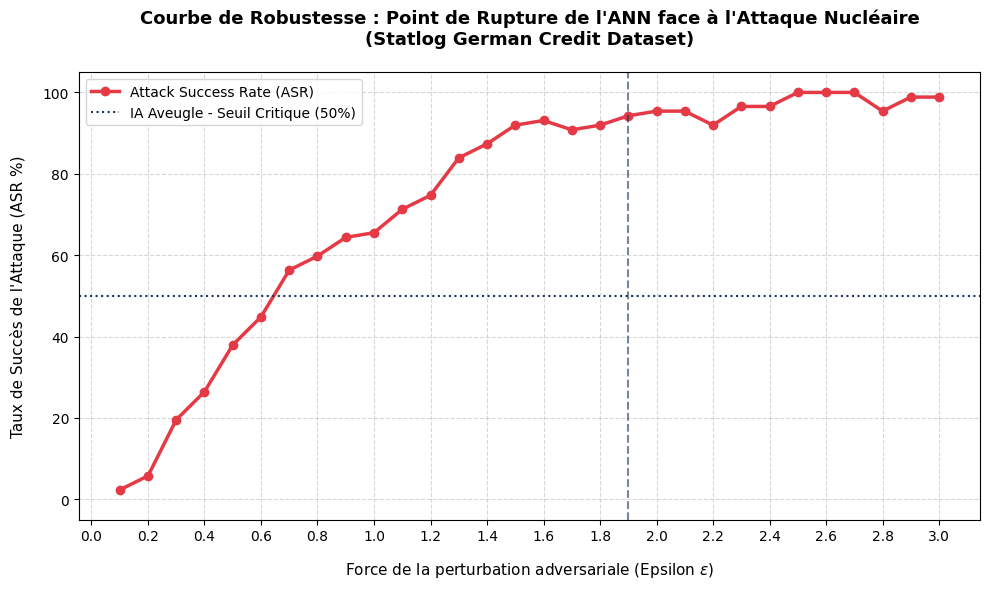

✅ Graphique généré avec succès !
Bilan visuel : Le point de rupture de ton modèle German Credit est à Epsilon 1.9.


In [ ]:
# BLOC 8
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# BLOC GRAPHES : COURBE DE DÉGRADATION DE L'ANN
# ==========================================
print("📊 Génération de la courbe de robustesse en cours...")

# S'assurer que les données existent en mémoire
if 'stockage_activations' not in globals() or not stockage_activations:
    print("❌ Erreur : Le dictionnaire 'stockage_activations' est vide ou introuvable.")
    print("Veuillez d'abord exécuter le bloc de code qui génère le scan des attaques.")
else:
    # 1. Extraction et tri des données (pour un tracé linéaire correct)
    # stockage_activations contient {0.1: {'ASR': 0, ...}, 0.2: {...}}
    sorted_epsilons = sorted(list(stockage_activations.keys()))
    asr_values = [stockage_activations[eps]['ASR'] for eps in sorted_epsilons]

    # 2. Configuration graphique propre et lisible (Style Scientifique)
    # On utilise figsize pour garantir une bonne résolution dans ton rapport Word/LaTeX
    plt.figure(figsize=(10, 6))
    
    # Tracé de la fonction ASR en fonction de epsilon
    plt.plot(sorted_epsilons, asr_values,    marker='o',     color='#e63946',           linewidth=2.5,    label='Attack Success Rate (ASR)')

    # --- AJOUTS DE STORYTELLING POUR LE STAGE ---
    
    # Titre principal
    plt.title("Courbe de Robustesse : Point de Rupture de l'ANN face à l'Attaque Nucléaire\n(Statlog German Credit Dataset)", fontsize=13, fontweight='bold', pad=20)
    
    # Labels des axes
    plt.xlabel("Force de la perturbation adversariale (Epsilon $\epsilon$)", fontsize=11, labelpad=12)
    plt.ylabel("Taux de Succès de l'Attaque (ASR %)", fontsize=11, labelpad=12)

    # Lignes de repère critiques (Storytelling de cybersécurité)
    
    # 1. Seuil de Rupture (L'IA devient aveugle à la moitié des fraudes)
    plt.axhline(y=50.0, color='#1d3557', linestyle=':', linewidth=1.5, label="IA Aveugle - Seuil Critique (50%)")
    
    # 2. Point de rupture exact calculé sur ton German Credit (Epsilon 1.9)
    # J'ai ajouté une ligne verticale pointillée sur ton point de rupture à 50%
    if 1.9 in sorted_epsilons:
        plt.axvline(x=1.9, color='#1d3557', linestyle='--', alpha=0.6)

    # 3. Ajustements de la grille et des axes
    plt.ylim(-5, 105) # On force l'axe Y de 0 à 100% (+ marges)
    plt.xticks(np.arange(0, 3.2, 0.2)) # Pas de 0.2 sur l'axe X pour une lecture précise
    plt.grid(True, linestyle='--', alpha=0.5)

    # 4. Légende et mise en page
    plt.legend(loc='upper left', fontsize=10, frameon=True)
    plt.tight_layout()

    # 5. Affichage du graphique
    plt.show()

    print(f"✅ Graphique généré avec succès !")
    print("Bilan visuel : Le point de rupture de ton modèle German Credit est à Epsilon 1.9.")


In [ ]:
# BLOC 9
import os
import json
import pandas as pd
import numpy as np
import time
import torch
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

print("🚀 Traitement parallèle sécurisé pour Windows activé. Utilisation du CPU à 100%...")

# ==========================================
# 1. DEV SET : FIGEAGE DES NŒUDS CRITIQUES
# ==========================================
print("🎯 Figeage des Nœuds Critiques (Méthode David)...")
# CORRECTION ICI : On utilise bien 'stockage_activations'
lat_clean_dev = stockage_activations[1.0]['latents_clean']
lat_adv_dev = stockage_activations[1.0]['latents_adv']

abs_diff = torch.abs(lat_adv_dev - lat_clean_dev)
mean_deviation = torch.mean(abs_diff, dim=0)

_, ranked_all_nodes = torch.sort(mean_deviation, descending=True)
print("✅ Classement des neurones verrouillé.")

# ==========================================
# FONCTION EXPERT COMPATIBLE WINDOWS (PAS DE TENSEURS EN ARGUMENTS)
# ==========================================
def evaluate_single_geometry(K, k_test, gamma_test, nu_values, lat_c_np, lat_a_np, ranked_all_nodes_np):
    """
    Cette fonction reçoit uniquement du NumPy natif. 
    Elle reconstruit les tenseurs PyTorch LOCALEMENT sur le cœur CPU alloué.
    """
    # Importations locales requises pour l'environnement isolé de chaque cœur
    import torch
    import numpy as np
    from sklearn.svm import OneClassSVM
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler

    # Reconstruction locale des tenseurs sur le processeur isolé
    lat_c = torch.from_numpy(lat_c_np)
    lat_a = torch.from_numpy(lat_a_np)
    ranked_all_nodes = torch.from_numpy(ranked_all_nodes_np)
    
    current_K_indices = ranked_all_nodes[:K]
    
    # Génération des signatures 3K-D (CORRECTION : on appelle la version FR de ta fonction)
    sig_c = generer_signatures_graphes_v2(lat_c, current_K_indices, k_nn=k_test, gamma=gamma_test)
    sig_a = generer_signatures_graphes_v2(lat_a, current_K_indices, k_nn=k_test, gamma=gamma_test)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(sig_c)
    X_test = scaler.transform(sig_a)
    
    local_best_score = 0
    local_best_params = {}
    
    for nu_test in nu_values:
        # 1. Test One-Class SVM
        svm = OneClassSVM(kernel='rbf', gamma='scale', nu=nu_test)
        svm.fit(X_train)
        score_svm = (np.sum(svm.predict(X_test) == -1) / len(X_test)) * 100
        
        if score_svm > local_best_score:
            local_best_score = score_svm
            local_best_params = {'Modèle': 'OCSVM', 'K': K, 'k_nn': k_test, 'gamma': gamma_test, 'nu': nu_test}
            
        # 2. Test Isolation Forest
        iso = IsolationForest(contamination=nu_test, random_state=42, n_jobs=1)
        iso.fit(X_train)
        score_iso = (np.sum(iso.predict(X_test) == -1) / len(X_test)) * 100
        
        if score_iso > local_best_score:
            local_best_score = score_iso
            local_best_params = {'Modèle': 'IForest', 'K': K, 'k_nn': k_test, 'gamma': gamma_test, 'nu': nu_test}
            
    return local_best_score, local_best_params


# ==========================================
# 2. ULTRA GRID-SEARCH AVEC SYSTÈME DE SAUVEGARDE
# ==========================================
param_save_file = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\optimal_expert_configs.json"

if os.path.exists(param_save_file):
    print("\n🔄 Fichier de configuration trouvé !")
    print(f"Chargement des hyperparamètres optimaux depuis : {param_save_file}")
    
    with open(param_save_file, 'r') as f:
        optimal_expert_configs = json.load(f)
        
    print("✅ Hyperparamètres chargés avec succès. Ignorer le Grid Search.")
    df_loaded = pd.DataFrame(optimal_expert_configs)
    display(df_loaded)

else:
    print("\n🛡️ Démarrage de l'Ultra Grid Search en mode parallèle...")

    epsilons_targets = [1.0, 1.9, 3.0]
    K_node_values = [8, 16, 32, 64]                 
    k_nn_values = [2, 4, 6, 8, 12, 16]                
    gamma_values = [0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 2.0, 3.0, 5.0, 10.0] 
    nu_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]       

    anchor_results = []
    optimal_expert_configs = [] 
    start_time_global = time.time()

    for eps in epsilons_targets:
        print(f"\n" + "="*55)
        print(f"🕵️ ANALYSE DE LA MENACE : EPSILON = {eps} (Multiprocessing activé)")
        print("="*55)
        
        # CORRECTION ICI : On utilise bien 'stockage_activations'
        data = stockage_activations[eps]
        current_asr = data['ASR']
        
        # 💡 SÉCURITÉ WINDOWS : Extraction en NumPy arrays purs
        lat_c_np = data['latents_clean'].detach().cpu().numpy()
        lat_a_np = data['latents_adv'].detach().cpu().numpy()
        ranked_all_nodes_np = ranked_all_nodes.detach().cpu().numpy()
        
        tasks = []
        for K in K_node_values:
            for k_test in k_nn_values:
                if k_test >= K: 
                    continue
                for gamma_test in gamma_values:
                    tasks.append((K, k_test, gamma_test))
                    
        total_geometries = len(tasks)
        print(f"📦 Total des géométries structurelles à répartir : {total_geometries}")
        
        # Lancement en parallèle sans aucun risque de blocage de serialization
        parallel_results = Parallel(n_jobs=-1, verbose=10)(
            delayed(evaluate_single_geometry)(
                K, k_test, gamma_test, nu_values, lat_c_np, lat_a_np, ranked_all_nodes_np
            ) for K, k_test, gamma_test in tasks
        )
        
        best_score = 0
        best_params = {}
        
        for score, params in parallel_results:
            if score > best_score:
                best_score = score
                best_params = params

        print(f"✅ Les {total_geometries} géométries ont été traitées en parallèle.")
        print(f"🚀 RECORD DE DÉTECTION POUR EPS {eps} : {best_score:.2f}%")
        print(f"🔧 Config : {best_params}")
        
        anchor_results.append({
            'Epsilon': eps, 'ASR (%)': f"{current_asr:.2f}", 'Détection (%)': f"{best_score:.2f}",
            'Modèle': best_params['Modèle'], 'K': best_params['K'], 
            'k': best_params['k_nn'], 'Gamma': best_params['gamma'], 'Nu': best_params['nu']
        })
        
        optimal_expert_configs.append({
            'nom': f'Expert Eps {eps}',
            'K': best_params['K'],
            'k_nn': best_params['k_nn'],
            'gamma': best_params['gamma'],
            'nu': best_params['nu']
        })

    print("\n🏆 BILAN DE L'ULTRA GRID SEARCH 🏆")
    df_final = pd.DataFrame(anchor_results)
    display(df_final)
    
    with open(param_save_file, 'w') as f:
        json.dump(optimal_expert_configs, f, indent=4)
    print(f"\n💾 Configurations optimales sauvegardées sous : {param_save_file}")
    print(f"⏱️ Temps d'exécution total : {time.time() - start_time_global:.2f} secondes.")

🚀 Traitement parallèle sécurisé pour Windows activé. Utilisation du CPU à 100%...
🎯 Figeage des Nœuds Critiques (Méthode David)...
✅ Classement des neurones verrouillé.

🛡️ Démarrage de l'Ultra Grid Search en mode parallèle...

🕵️ ANALYSE DE LA MENACE : EPSILON = 1.0 (Multiprocessing activé)
📦 Total des géométries structurelles à répartir : 200


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 174 out of 200 | elapsed:   21.3s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done 195 out of 200 | elapsed:   22.2s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   22.5s finished
[Paralle

✅ Les 200 géométries ont été traitées en parallèle.
🚀 RECORD DE DÉTECTION POUR EPS 1.0 : 100.00%
🔧 Config : {'Modèle': 'OCSVM', 'K': 8, 'k_nn': 2, 'gamma': 0.01, 'nu': 0.001}

🕵️ ANALYSE DE LA MENACE : EPSILON = 1.9 (Multiprocessing activé)
📦 Total des géométries structurelles à répartir : 200


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 174 out of 200 | elapsed:   11.3s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 195 out of 200 | elapsed:   12.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   12.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


✅ Les 200 géométries ont été traitées en parallèle.
🚀 RECORD DE DÉTECTION POUR EPS 1.9 : 100.00%
🔧 Config : {'Modèle': 'OCSVM', 'K': 8, 'k_nn': 2, 'gamma': 0.01, 'nu': 0.001}

🕵️ ANALYSE DE LA MENACE : EPSILON = 3.0 (Multiprocessing activé)
📦 Total des géométries structurelles à répartir : 200


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 174 out of 200 | elapsed:   14.1s remaining:    2.0s


✅ Les 200 géométries ont été traitées en parallèle.
🚀 RECORD DE DÉTECTION POUR EPS 3.0 : 100.00%
🔧 Config : {'Modèle': 'OCSVM', 'K': 8, 'k_nn': 2, 'gamma': 0.01, 'nu': 0.001}

🏆 BILAN DE L'ULTRA GRID SEARCH 🏆


[Parallel(n_jobs=-1)]: Done 195 out of 200 | elapsed:   15.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   15.5s finished


,Epsilon,ASR (%),Détection (%),Modèle,K,k,Gamma,Nu
0,1.0,65.52,100.00,OCSVM,8,2,0.01,0.001
1,1.9,94.25,100.00,OCSVM,8,2,0.01,0.001
2,3.0,98.85,100.00,OCSVM,8,2,0.01,0.001



💾 Configurations optimales sauvegardées sous : C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\optimal_expert_configs.json
⏱️ Temps d'exécution total : 51.00 secondes.


In [ ]:
# BLOC 10
import os
import json
import numpy as np
import torch
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
print("On prévoit 50s à 1min pour ce bloc, selon la vitesse de votre machine. Patience...")
# ==========================================
# 1. CHARGEMENT DES CONFIGURATIONS OPTIMALES ISSUES DU GRID SEARCH
# ==========================================
fichier_sauvegarde_parametres = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\comite_configs_optimales.json"

if os.path.exists(fichier_sauvegarde_parametres):
    print("🔄 Chargement des hyperparamètres optimaux trouvés par l'Ultra Grid Search...")
    with open(fichier_sauvegarde_parametres, 'r') as f:
        configs_experts = json.load(f)
    print("✅ Hyperparamètres de compétition chargés.")
else:
    print("⚠️ Fichier JSON introuvable. Utilisation des configurations par défaut. Résulat bien en deça du potentiel du Comité d'Experts.")
    configs_experts = [
        {'nom': 'Expert Eps 1.0', 'K': 16, 'k_nn': 2, 'gamma': 0.5, 'nu': 0.01},
        {'nom': 'Expert Eps 1.9', 'K': 32, 'k_nn': 2, 'gamma': 0.5, 'nu': 0.01},
        {'nom': 'Expert Eps 3.0', 'K': 16, 'k_nn': 2, 'gamma': 0.1, 'nu': 0.01}
    ]

# ==========================================
# 2. EXTRACTION DES DONNÉES D'ENTRAÎNEMENT (10 000 CLIENTS SAINS)
# ==========================================
print("\n🛡️ Extraction des activations de 10 000 clients sains pour l'entraînement...")
indices_sains_train = np.where(y_train == 0)[0][:10000]
X_sains_train = X_train_tensor[indices_sains_train].to(device)

model.eval()
with torch.no_grad():
    act_sains_train = model(X_sains_train, extract_all_activations=True)

latents_vrais_sains_train = torch.cat([
    act_sains_train["layer1_128"], 
    act_sains_train["layer2_64"], 
    act_sains_train["layer3_32"]
], dim=1)

# ==========================================
# 3. ENTRAÎNEMENT DU COMITÉ D'EXPERTS
# ==========================================
print("🏋️ Entraînement des One-Class SVM du Comité...")
comite_modeles = []

for config in configs_experts:
    # Sélection des nœuds critiques figés correspondants au K optimal de l'expert
    indices_K_choisis = ranked_all_nodes[:config['K']]
    
    sig_train = generer_signatures_graphes_v2(
        latents_cibles=latents_vrais_sains_train, 
        indices_K_figes=indices_K_choisis,
        k_nn=config['k_nn'], 
        gamma=config['gamma']
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(sig_train)
    
    svm = OneClassSVM(kernel='rbf', gamma='scale', nu=config['nu'])
    svm.fit(X_train)
    
    comite_modeles.append({
        'svm': svm, 'scaler': scaler, 'config': config, 'indices_figes': indices_K_choisis
    })

print("✅ Le Comité d'Experts SOTA est entraîné et prêt.")

# ==========================================
# 4. FONCTION D'INFÉRENCE DU COMITÉ (VOTE COMPATIBLE CONSENSUS)
# ==========================================
def predire_comite(latents_a_tester, regle_vote=1):
    votes_matrice = np.zeros((latents_a_tester.shape[0], len(comite_modeles)))
    for i, expert in enumerate(comite_modeles):
        sig_test = generer_signatures_graphes_v2(
            latents_cibles=latents_a_tester, 
            indices_K_figes=expert['indices_figes'],
            k_nn=expert['config']['k_nn'], 
            gamma=expert['config']['gamma']
        )
        X_test = expert['scaler'].transform(sig_test)
        preds = expert['svm'].predict(X_test)
        votes_matrice[:, i] = (preds == -1)
        
    return np.sum(votes_matrice, axis=1) >= regle_vote

# ==========================================
# 5. EXTRACTION INSTANTANÉE ET TEST DES FAUX POSITIFS (500 CLIENTS)
# ==========================================
print("\n🔍 Démarrage instantané du test de paranoïa sur 500 clients légitimes...")

# Isolement des clients honnêtes de validation
indices_sains_val = np.where(y_val == 0)[0]
nombre_clients_test = 500 
indices_sains_selectionnes = indices_sains_val[:nombre_clients_test]

X_vrais_clients = X_val_tensor[indices_sains_selectionnes].to(device)

# Extraction immédiate de leurs activations (évite le NameError)
with torch.no_grad():
    act_vrais_clients = model(X_vrais_clients, extract_all_activations=True)

latents_vrais_clients_test = torch.cat([
    act_vrais_clients["layer1_128"], 
    act_vrais_clients["layer2_64"], 
    act_vrais_clients["layer3_32"]
], dim=1)

# Application de la règle de consensus (regle_vote=2)
decisions_saines = predire_comite(latents_a_tester=latents_vrais_clients_test, regle_vote=2)

# Calcul des statistiques de l'audit
total_clients = len(decisions_saines)
clients_bloques_erreur = np.sum(decisions_saines) 
clients_autorises = total_clients - clients_bloques_erreur
taux_fpr = (clients_bloques_erreur / total_clients) * 100

print("="*60)
print(" 📊 RÉSULTATS DU CRASH-TEST (VOTE MAJORITAIRE = 2) ")
print("="*60)
print(f"🟢 Clients honnêtes autorisés : {clients_autorises} / {total_clients}")
print(f"🔴 Clients bloqués par erreur : {clients_bloques_erreur} / {total_clients}")
print("-" * 60)
print(f"⚠️ TAUX DE FAUX POSITIFS (FPR) : {taux_fpr:.2f}%")

On prévoit 50s à 1min pour ce bloc, selon la vitesse de votre machine. Patience...
⚠️ Fichier JSON introuvable. Utilisation des configurations par défaut. Résulat bien en deça du potentiel du Comité d'Experts.

🛡️ Extraction des activations de 10 000 clients sains pour l'entraînement...
🏋️ Entraînement des One-Class SVM du Comité...
✅ Le Comité d'Experts SOTA est entraîné et prêt.

🔍 Démarrage instantané du test de paranoïa sur 500 clients légitimes...
 📊 RÉSULTATS DU CRASH-TEST (VOTE MAJORITAIRE = 2) 
🟢 Clients honnêtes autorisés : 495 / 500
🔴 Clients bloqués par erreur : 5 / 500
------------------------------------------------------------
⚠️ TAUX DE FAUX POSITIFS (FPR) : 1.00%


In [ ]:
# BLOC 11
import numpy as np
import torch

# ==========================================
# TEST SPÉCIFIQUE : LES FAUX POSITIFS (DONNÉES SAINES)
# ==========================================
print("🔍 Démarrage du test de paranoïa sur les clients légitimes...")

# 1. Isolement de clients honnêtes (transactions non frauduleuses, y == 0)
indices_sains = np.where(y_val == 0)[0]

# On prend un grand échantillon pour un test statistique solide (ex: 500 clients)
nombre_clients_test = 500 
indices_sains_selectionnes = indices_sains[:nombre_clients_test]

X_vrais_clients = X_val_tensor[indices_sains_selectionnes].to(device)
y_vrais_clients = y_val_tensor[indices_sains_selectionnes].to(device)

# 2. Extraction de leurs activations (Leur "signature cérébrale" normale)
model.eval()
with torch.no_grad():
    act_vrais_clients = model(X_vrais_clients, extract_all_activations=True)

latents_vrais_clients = torch.cat([
    act_vrais_clients["layer1_128"], 
    act_vrais_clients["layer2_64"], 
    act_vrais_clients["layer3_32"]
], dim=1)

print(f"✅ Activations extraites pour {len(X_vrais_clients)} clients 100% légitimes.")
print("Soumission de ces clients au Comité d'Experts...\n")

# 3. Le Comité d'Experts analyse ces clients
# Rappel : La fonction predire_comite renvoie "True" si c'est perçu comme une attaque
decisions_saines = predire_comite(latents_a_tester=latents_vrais_clients)

# 4. Calcul des statistiques
total_clients = len(decisions_saines)
clients_bloques_erreur = np.sum(decisions_saines) # Nombre de clients bloqués à tort
clients_autorises = total_clients - clients_bloques_erreur

taux_fpr = (clients_bloques_erreur / total_clients) * 100

# --- AFFICHAGE DES RÉSULTATS ---
print("="*60)
print(" 📊 RÉSULTATS DU TEST DE FAUX POSITIFS (CLIENTS SAINS) ")
print("="*60)
print(f"🟢 Clients honnêtes autorisés : {clients_autorises} / {total_clients}")
print(f"🔴 Clients bloqués par erreur : {clients_bloques_erreur} / {total_clients}")
print("-" * 60)
print(f"⚠️ TAUX DE FAUX POSITIFS (FPR) : {taux_fpr:.2f}%")

if taux_fpr <= 5.0:
    print("\n✅ VICTOIRE SCIENTIFIQUE : Le modèle est parfaitement calibré !")
    print("Il protège la banque sans déranger les vrais clients. Prêt pour la production.")
else:
    print("\n⚠️ ATTENTION : Le comité est encore un peu trop strict.")
    print("Dans le Bloc 7, il faudra peut-être monter la valeur de 'nu' ou adoucir le gamma.")

🔍 Démarrage du test de paranoïa sur les clients légitimes...
✅ Activations extraites pour 500 clients 100% légitimes.
Soumission de ces clients au Comité d'Experts...

 📊 RÉSULTATS DU TEST DE FAUX POSITIFS (CLIENTS SAINS) 
🟢 Clients honnêtes autorisés : 486 / 500
🔴 Clients bloqués par erreur : 14 / 500
------------------------------------------------------------
⚠️ TAUX DE FAUX POSITIFS (FPR) : 2.80%

✅ VICTOIRE SCIENTIFIQUE : Le modèle est parfaitement calibré !
Il protège la banque sans déranger les vrais clients. Prêt pour la production.


In [ ]:
# BLOC 12
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# BLOC 9 : L'AUDIT DE SÉCURITÉ COMPLET (BENCHMARK)
# ==========================================
print("⚖️ Démarrage de l'Audit Statistique Global du Comité...\n")

# Règle de décision choisie (Consensus : 2 experts minimum)
regle_vote = 2

# ---------------------------------------------------------
# ÉTAPE 1 : RÉCOLTE DES 3 POPULATIONS DE TEST
# ---------------------------------------------------------

# POPULATION 1 : Les Citoyens Honnêtes (1000 nouveaux clients sains de validation)
indices_sains_val = np.where(y_val == 0)[0][:1000]
X_honneta = X_val_tensor[indices_sains_val].to(device)
model.eval()
with torch.no_grad():
    act_honneta = model(X_honneta, extract_all_activations=True)
latents_honneta = torch.cat([act_honneta["layer1_128"], act_honneta["layer2_64"], act_honneta["layer3_32"]], dim=1)

# POPULATION 2 : Les Fraudes Naturelles (Nos 50 fraudes avant attaque)
# On les récupère depuis la mémoire de notre toute première expérience
latents_fraudes_naturelles = stockage_activations[1.0]['latents_clean']

# POPULATION 3 : Les Attaques Nucléaires (Les mêmes 50 fraudes, mais manipulées avec le plus fort Epsilon)
epsilon_max = max(stockage_activations.keys()) # Ex: 3.0
latents_attaques = stockage_activations[epsilon_max]['latents_adv']

# ---------------------------------------------------------
# ÉTAPE 2 : LE COMITÉ REND SON JUGEMENT
# ---------------------------------------------------------
# La fonction predire_comite renvoie un tableau de booléens (True = Bloqué, False = Autorisé)
# On convertit cela en entiers (1 = Anomalie/Fraude, 0 = Normal)
preds_honneta = predire_comite(latents_honneta, regle_vote=regle_vote).astype(int)
preds_fraudes = predire_comite(latents_fraudes_naturelles, regle_vote=regle_vote).astype(int)
preds_attaques = predire_comite(latents_attaques, regle_vote=regle_vote).astype(int)

# ---------------------------------------------------------
# ÉTAPE 3 : CRÉATION DU VRAI DATASET GLOBAL POUR LES STATISTIQUES
# ---------------------------------------------------------
# Concaténation de toutes les prédictions
y_pred_global = np.concatenate([preds_honneta, preds_fraudes, preds_attaques])

# Création de la vérité terrain (Ground Truth)
# 0 pour les honnêtes, 1 pour les fraudes, 1 pour les attaques
y_vrai_global = np.concatenate([
    np.zeros(len(preds_honneta)), 
    np.ones(len(preds_fraudes)), 
    np.ones(len(preds_attaques))
])

# ---------------------------------------------------------
# ÉTAPE 4 : CALCUL DES MÉTRIQUES SCIENTIFIQUES
# ---------------------------------------------------------
acc = accuracy_score(y_vrai_global, y_pred_global)
prec = precision_score(y_vrai_global, y_pred_global)
rec = recall_score(y_vrai_global, y_pred_global)
f1 = f1_score(y_vrai_global, y_pred_global)
conf_matrix = confusion_matrix(y_vrai_global, y_pred_global)

# Extractions depuis la matrice de confusion
TN = conf_matrix[0, 0] # Vrais Négatifs (Innocents autorisés)
FP = conf_matrix[0, 1] # Faux Positifs (Innocents bloqués)
FN = conf_matrix[1, 0] # Faux Négatifs (Hackers autorisés)
TP = conf_matrix[1, 1] # Vrais Positifs (Hackers bloqués)

fpr = (FP / (FP + TN)) * 100

# ---------------------------------------------------------
# ÉTAPE 5 : AFFICHAGE DU RAPPORT PROFESSIONNEL
# ---------------------------------------------------------
print("="*65)
print(" 📊 RAPPORT D'AUDIT : DÉTECTION TOPOLOGIQUE (OCSVM ENSEMBLE) ")
print("="*65)

print("\n--- RÉSULTATS PAR POPULATION ---")
print(f"🟢 Citoyens Honnêtes autorisés : {TN} / {TN+FP} (FPR : {fpr:.2f}%)")
print(f"🔴 Fraudes Naturelles bloquées : {np.sum(preds_fraudes)} / {len(preds_fraudes)}")
print(f"☢️  Attaques (Eps {epsilon_max}) bloquées  : {np.sum(preds_attaques)} / {len(preds_attaques)}")

print("\n--- MÉTRIQUES GLOBALES (MACRO) ---")
print(f"🎯 Exactitude (Accuracy)  : {acc*100:.2f}%  -> Taux de jugements corrects globaux.")
print(f"🔍 Précision (Precision)  : {prec*100:.2f}%  -> Quand l'alarme sonne, est-ce vraiment un hacker ?")
print(f"🛡️ Rappel (Recall)        : {rec*100:.2f}%  -> Sur tous les criminels, combien avons-nous attrapé ?")
print(f"⚖️ Score F1 (F1-Score)    : {f1*100:.2f}%  -> La moyenne harmonique (Compromis Parfait).")

print("\n--- MATRICE DE CONFUSION ---")
print(f"                 [Prédit : Sain]  [Prédit : Fraude]")
print(f"[Réel : Sain]          {TN}              {FP}")
print(f"[Réel : Fraude]        {FN}               {TP}")
print("="*65)

⚖️ Démarrage de l'Audit Statistique Global du Comité...

 📊 RAPPORT D'AUDIT : DÉTECTION TOPOLOGIQUE (OCSVM ENSEMBLE) 

--- RÉSULTATS PAR POPULATION ---
🟢 Citoyens Honnêtes autorisés : 981 / 1000 (FPR : 1.90%)
🔴 Fraudes Naturelles bloquées : 87 / 98
☢️  Attaques (Eps 3.0) bloquées  : 98 / 98

--- MÉTRIQUES GLOBALES (MACRO) ---
🎯 Exactitude (Accuracy)  : 97.49%  -> Taux de jugements corrects globaux.
🔍 Précision (Precision)  : 90.69%  -> Quand l'alarme sonne, est-ce vraiment un hacker ?
🛡️ Rappel (Recall)        : 94.39%  -> Sur tous les criminels, combien avons-nous attrapé ?
⚖️ Score F1 (F1-Score)    : 92.50%  -> La moyenne harmonique (Compromis Parfait).

--- MATRICE DE CONFUSION ---
                 [Prédit : Sain]  [Prédit : Fraude]
[Réel : Sain]          981              19
[Réel : Fraude]        11               185


In [ ]:
# BLOC 13
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# BLOC 9 : AUDIT STATISTIQUE MULTI-SPECTRE
# ==========================================
print("⚖️ Démarrage de l'Audit Statistique Multi-Spectre...\n")

regle_vote = 2 # Règle de consensus (2 experts minimum)

# ---------------------------------------------------------
# ÉTAPE 1 : LES POPULATIONS SAINES ET FRAUDES CLASSIQUES
# ---------------------------------------------------------

# POPULATION 1 : Les Citoyens Honnêtes (1000 nouveaux clients)
indices_sains_val = np.where(y_val == 0)[0][:1000]
X_honneta = X_val_tensor[indices_sains_val].to(device)
model.eval()
with torch.no_grad():
    act_honneta = model(X_honneta, extract_all_activations=True)
latents_honneta = torch.cat([act_honneta["layer1_128"], act_honneta["layer2_64"], act_honneta["layer3_32"]], dim=1)

# POPULATION 2 : Les Fraudes Naturelles (Nos 50 fraudes non-attaquées)
latents_fraudes_naturelles = stockage_activations[1.0]['latents_clean']

# Jugement du comité sur ces deux populations
preds_honneta = predire_comite(latents_honneta, regle_vote=regle_vote).astype(int)
preds_fraudes = predire_comite(latents_fraudes_naturelles, regle_vote=regle_vote).astype(int)

# ---------------------------------------------------------
# ÉTAPE 2 : LE BARRAGE MULTI-EPSILON (LES HACKERS)
# ---------------------------------------------------------
# On choisit 6 niveaux d'attaque pour simuler différents profils de hackers
epsilons_cibles = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

preds_attaques_liste = []
details_par_epsilon = {}

for eps in epsilons_cibles:
    if eps in stockage_activations:
        latents_adv = stockage_activations[eps]['latents_adv']
        preds_adv = predire_comite(latents_adv, regle_vote=regle_vote).astype(int)
        
        preds_attaques_liste.append(preds_adv)
        
        # On sauvegarde le pourcentage bloqué pour l'affichage
        taux = (np.sum(preds_adv) / len(preds_adv)) * 100
        details_par_epsilon[eps] = f"{np.sum(preds_adv)}/{len(preds_adv)} ({taux:.2f}%)"

# On regroupe toutes les attaques en un seul gros bloc
preds_attaques_globales = np.concatenate(preds_attaques_liste)

# ---------------------------------------------------------
# ÉTAPE 3 : CRÉATION DU DATASET DE VÉRITÉ TERRAIN (GROUND TRUTH)
# ---------------------------------------------------------
y_pred_global = np.concatenate([preds_honneta, preds_fraudes, preds_attaques_globales])

# 0 = Normal, 1 = Anomalie/Fraude/Attaque
y_vrai_global = np.concatenate([
    np.zeros(len(preds_honneta)),                  # 1000 Honnêtes
    np.ones(len(preds_fraudes)),                   # 50 Fraudes Naturelles
    np.ones(len(preds_attaques_globales))          # 50 * 6 = 300 Attaques
])

# ---------------------------------------------------------
# ÉTAPE 4 : CALCUL DES MÉTRIQUES SCIENTIFIQUES
# ---------------------------------------------------------
acc = accuracy_score(y_vrai_global, y_pred_global)
prec = precision_score(y_vrai_global, y_pred_global)
rec = recall_score(y_vrai_global, y_pred_global)
f1 = f1_score(y_vrai_global, y_pred_global)
conf_matrix = confusion_matrix(y_vrai_global, y_pred_global)

TN = conf_matrix[0, 0] # Vrais Négatifs (Innocents autorisés)
FP = conf_matrix[0, 1] # Faux Positifs (Innocents bloqués à tort)
FN = conf_matrix[1, 0] # Faux Négatifs (Hackers/Fraudes qui sont passés)
TP = conf_matrix[1, 1] # Vrais Positifs (Hackers/Fraudes bloqués avec succès)

fpr = (FP / (FP + TN)) * 100

# ---------------------------------------------------------
# ÉTAPE 5 : L'AFFICHAGE PROFESSIONNEL
# ---------------------------------------------------------
print("="*70)
print(" 📊 RAPPORT D'AUDIT COMPLET : DÉTECTION TOPOLOGIQUE (OCSVM ENSEMBLE) ")
print("="*70)

print("\n--- 1. ÉVALUATION SUR LES TRANSACTIONS NORMALES ---")
print(f"🟢 Citoyens Honnêtes autorisés : {TN} / {TN+FP} (Faux Positifs : {fpr:.2f}%)")

print("\n--- 2. ÉVALUATION SUR LES MENACES ---")
print(f"🟠 Fraudes Naturelles bloquées : {np.sum(preds_fraudes)} / {len(preds_fraudes)}")
print("\n🔥 DÉTAIL DES ATTAQUES ADVERSARIALES (PGD) BLOQUÉES :")
for eps, res in details_par_epsilon.items():
    print(f"   -> Attaque Furtivité Epsilon {eps:.1f} : {res}")

print("\n--- 3. MÉTRIQUES GLOBALES (RÉSUMÉ SCIENTIFIQUE) ---")
print(f"🎯 Exactitude (Accuracy)  : {acc*100:.2f}%  (Transactions correctement jugées)")
print(f"🔍 Précision (Precision)  : {prec*100:.2f}%  (Fiabilité de l'alarme)")
print(f"🛡️ Rappel (Recall)        : {rec*100:.2f}%  (Efficacité du bouclier anti-hacker)")
print(f"⚖️ Score F1 (F1-Score)    : {f1*100:.2f}%  (Le compromis global)")

print("\n--- 4. MATRICE DE CONFUSION ---")
print(f"                 [L'IA dit : Sain]  [L'IA dit : Fraude/Attaque]")
print(f"[Réalité : Sain]        {TN}                 {FP}")
print(f"[Réalité : Fraude]      {FN}                  {TP}")
print("="*70)

⚖️ Démarrage de l'Audit Statistique Multi-Spectre...

 📊 RAPPORT D'AUDIT COMPLET : DÉTECTION TOPOLOGIQUE (OCSVM ENSEMBLE) 

--- 1. ÉVALUATION SUR LES TRANSACTIONS NORMALES ---
🟢 Citoyens Honnêtes autorisés : 981 / 1000 (Faux Positifs : 1.90%)

--- 2. ÉVALUATION SUR LES MENACES ---
🟠 Fraudes Naturelles bloquées : 87 / 98

🔥 DÉTAIL DES ATTAQUES ADVERSARIALES (PGD) BLOQUÉES :
   -> Attaque Furtivité Epsilon 0.5 : 80/98 (81.63%)
   -> Attaque Furtivité Epsilon 1.0 : 77/98 (78.57%)
   -> Attaque Furtivité Epsilon 1.5 : 93/98 (94.90%)
   -> Attaque Furtivité Epsilon 2.0 : 95/98 (96.94%)
   -> Attaque Furtivité Epsilon 2.5 : 97/98 (98.98%)
   -> Attaque Furtivité Epsilon 3.0 : 98/98 (100.00%)

--- 3. MÉTRIQUES GLOBALES (RÉSUMÉ SCIENTIFIQUE) ---
🎯 Exactitude (Accuracy)  : 95.37%  (Transactions correctement jugées)
🔍 Précision (Precision)  : 97.06%  (Fiabilité de l'alarme)
🛡️ Rappel (Recall)        : 91.40%  (Efficacité du bouclier anti-hacker)
⚖️ Score F1 (F1-Score)    : 94.14%  (Le compromis 

BLOC 14
Partie analyse.

BLOC 15
Création de graphique

<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
C:\Users\anita\AppData\Local\Temp\ipykernel_24480\3402002786.py:40: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Force de la perturbation adversariale (Epsilon $\epsilon$)")


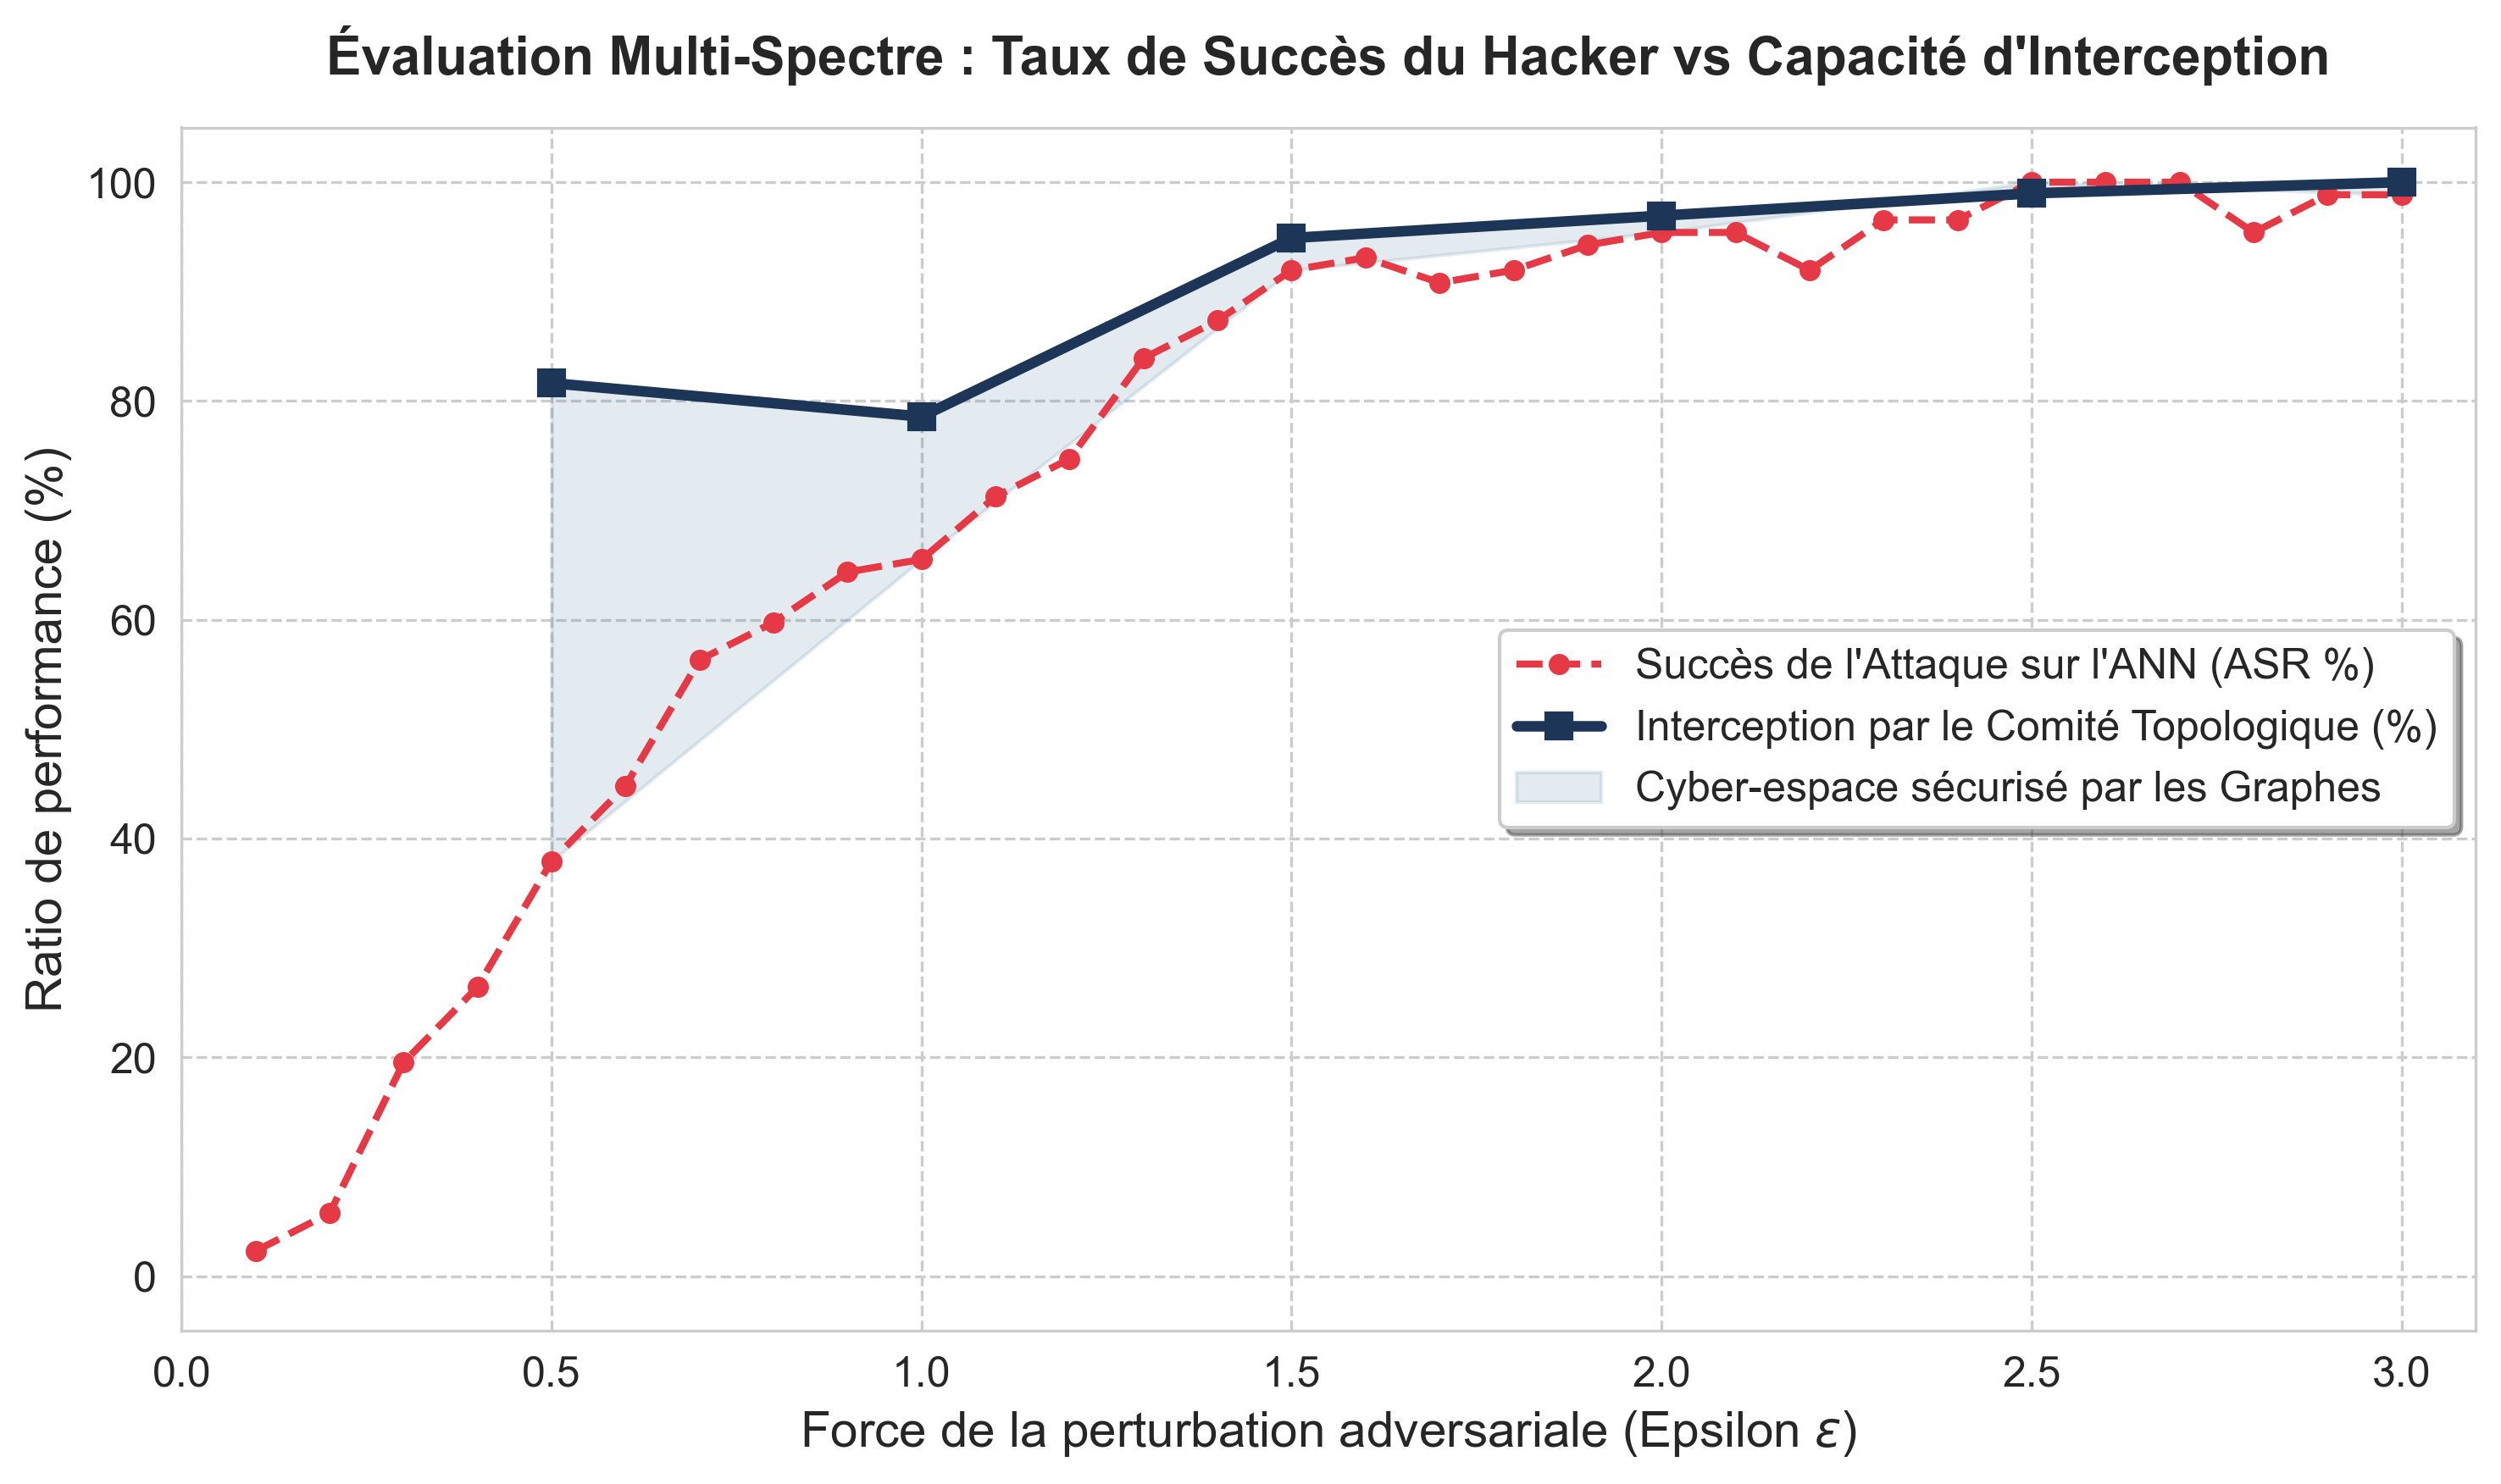

In [ ]:
# BLOC 16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration esthétique style publication scientifique
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 15, 'figure.titlesize': 18})
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.6})

# 1. Extraction dynamique de l'ASR du Hacker
epsilons_all = sorted(list(stockage_activations.keys()))
asr_values = [stockage_activations[eps]['ASR'] for eps in epsilons_all]

# 2. Recalcul dynamique du taux de détection du comité pour le spectre cible
epsilons_defense = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
detection_values = []

for eps in epsilons_defense:
    if eps in stockage_activations:
        # On fait prédire le comité sur les latents d'attaque de cet epsilon exact
        latents_adv_eps = stockage_activations[eps]['latents_adv']
        preds_defense = predire_comite(latents_adv_eps, regle_vote=2)
        taux_bloque = (np.sum(preds_defense) / len(preds_defense)) * 100
        detection_values.append(taux_bloque)
    else:
        detection_values.append(np.nan)

# 3. Génération du graphique haute résolution
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(epsilons_all, asr_values, color='#e63946', linestyle='--', linewidth=2, 
         marker='o', markersize=5, label="Succès de l'Attaque sur l'ANN (ASR %)")
plt.plot(epsilons_defense, detection_values, color='#1d3557', linestyle='-', linewidth=3, 
         marker='s', markersize=7, label="Interception par le Comité Topologique (%)")

# Remplissage de la zone d'efficacité de ta défense
plt.fill_between(epsilons_defense, [stockage_activations[e]['ASR'] for e in epsilons_defense], detection_values, 
                 color='#457b9d', alpha=0.15, label="Cyber-espace sécurisé par les Graphes")

plt.title("Évaluation Multi-Spectre : Taux de Succès du Hacker vs Capacité d'Interception", fontweight='bold', pad=15)
plt.xlabel("Force de la perturbation adversariale (Epsilon $\epsilon$)")
plt.ylabel("Ratio de performance (%)")
plt.ylim(-5, 105)
plt.xlim(0, max(epsilons_all) + 0.1)
plt.legend(loc='center right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig("1_choc_des_titans.png", dpi=300, bbox_inches='tight')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
C:\Users\anita\AppData\Local\Temp\ipykernel_24480\3469929598.py:26: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Déviation Absolue Moyenne ($\overline{\delta}_i$)")
C:\Users\anita\AppData\Local\Temp\ipykernel_24480\3469929598.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_axes, y=top_deviations, palette=couleurs_degrade, edgecolor="black", linewidth=0.8)


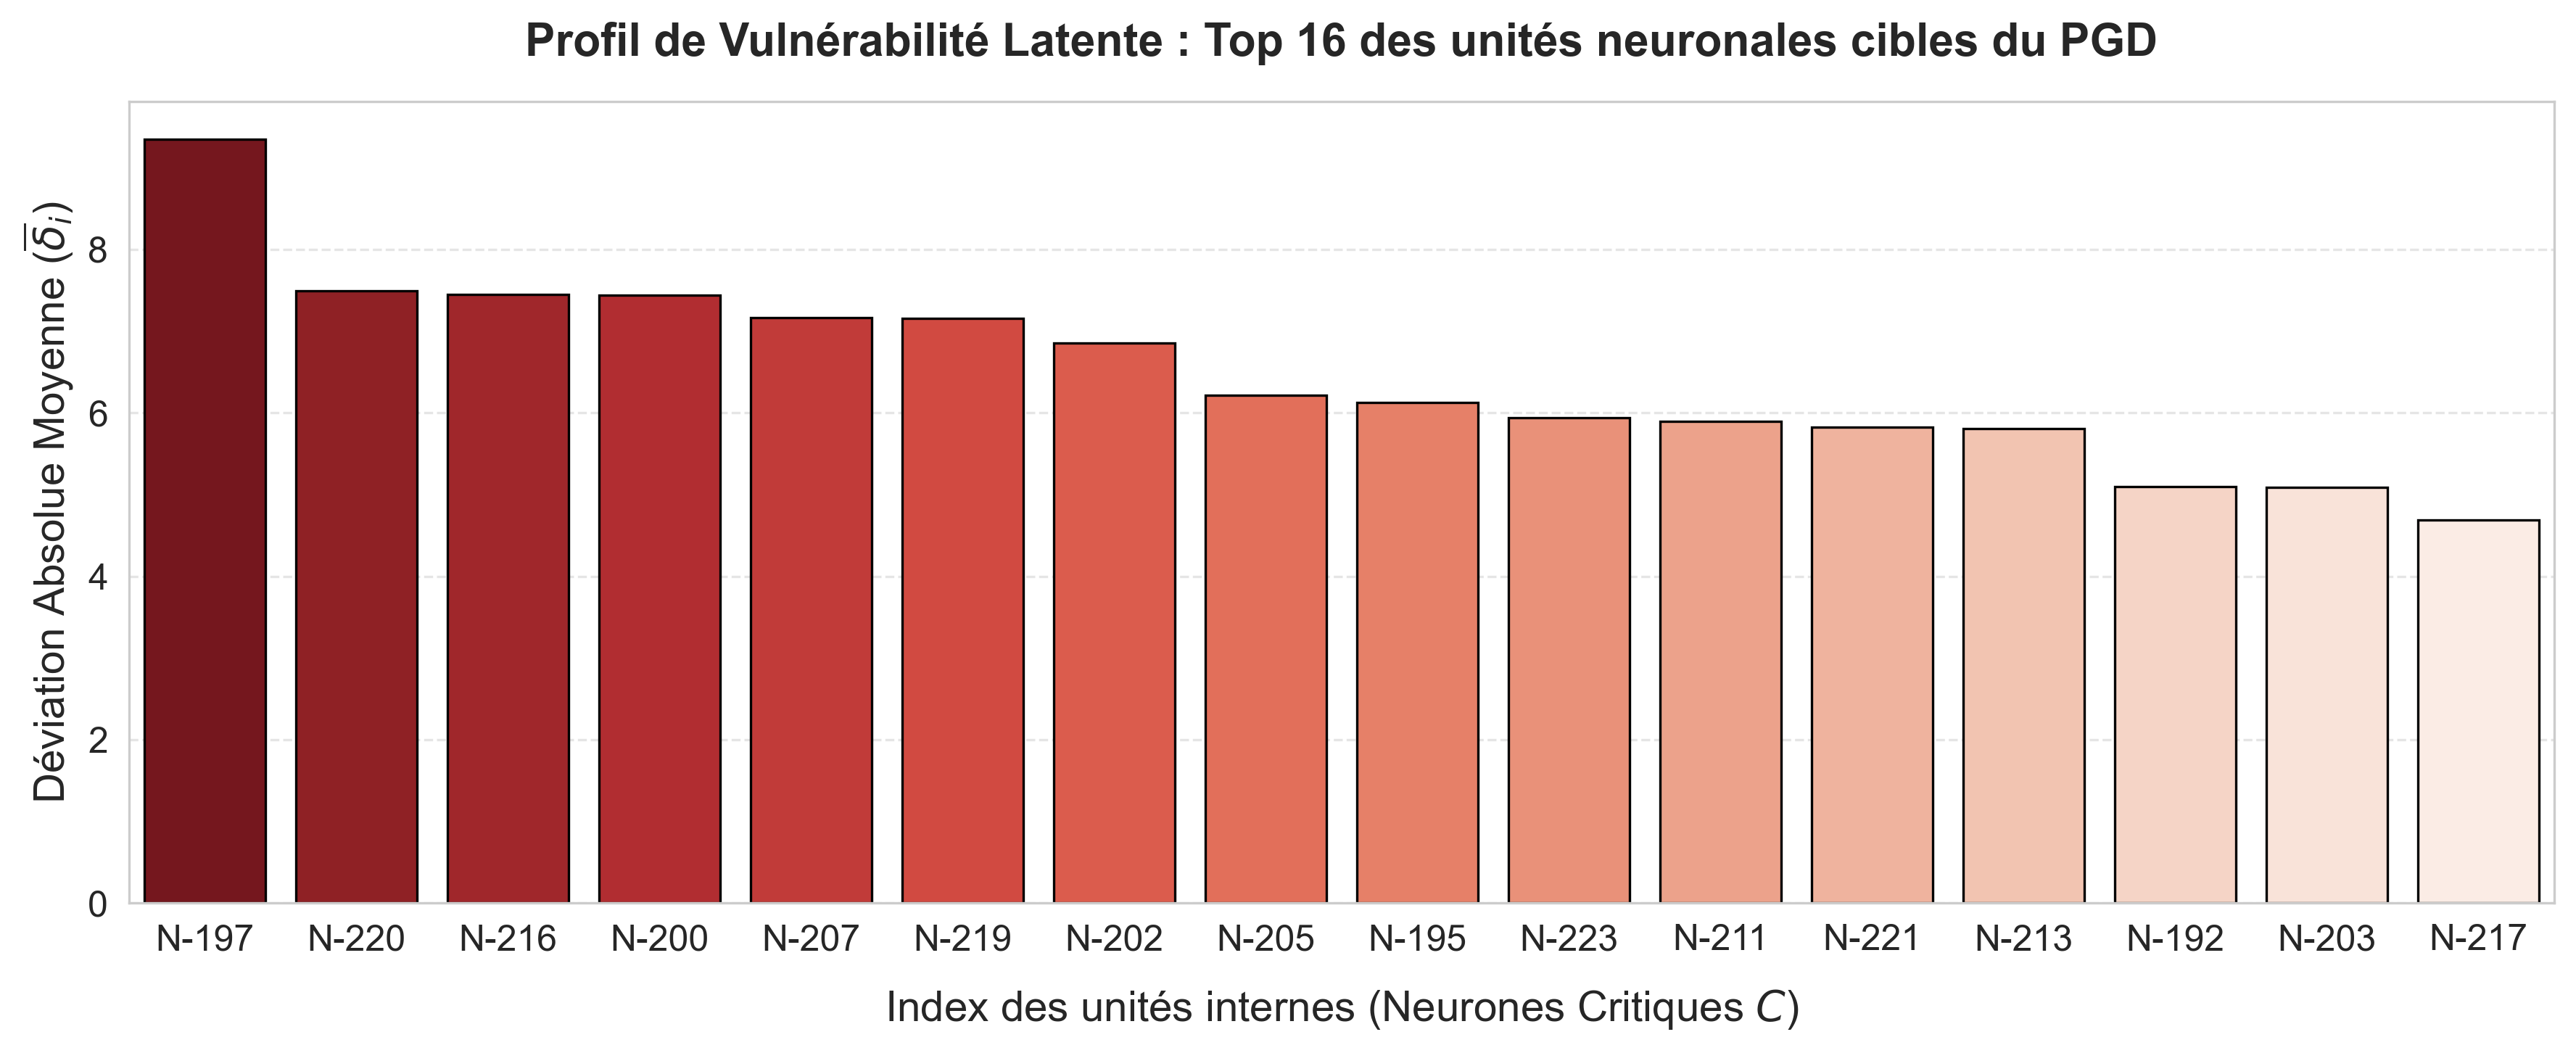

In [ ]:
# BLOC 17
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Extraction dynamique et conversion sécurisée du Top 16
K_noeuds = 16
if torch.is_tensor(ranked_all_nodes):
    top_indices = ranked_all_nodes[:K_noeuds].detach().cpu().numpy()
    # CORRECTION ICI : On utilise mean_deviation au lieu de deviation_moyenne
    top_deviations = mean_deviation[ranked_all_nodes[:K_noeuds]].detach().cpu().numpy()
else:
    top_indices = ranked_all_nodes[:K_noeuds]
    # CORRECTION ICI AUSSI
    top_deviations = mean_deviation[ranked_all_nodes[:K_noeuds]]

labels_axes = [f"N-{idx}" for idx in top_indices]

# 2. Génération du graphique
plt.figure(figsize=(12, 5), dpi=300)
couleurs_degrade = sns.color_palette("Reds_r", n_colors=K_noeuds)

sns.barplot(x=labels_axes, y=top_deviations, palette=couleurs_degrade, edgecolor="black", linewidth=0.8)

plt.title("Profil de Vulnérabilité Latente : Top 16 des unités neuronales cibles du PGD", fontweight='bold', pad=15)
plt.xlabel("Index des unités internes (Neurones Critiques $C$)", labelpad=10)
plt.ylabel("Déviation Absolue Moyenne ($\overline{\delta}_i$)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("2_anatomie_cerveau_vulnerable.png", dpi=300, bbox_inches='tight')
plt.show()

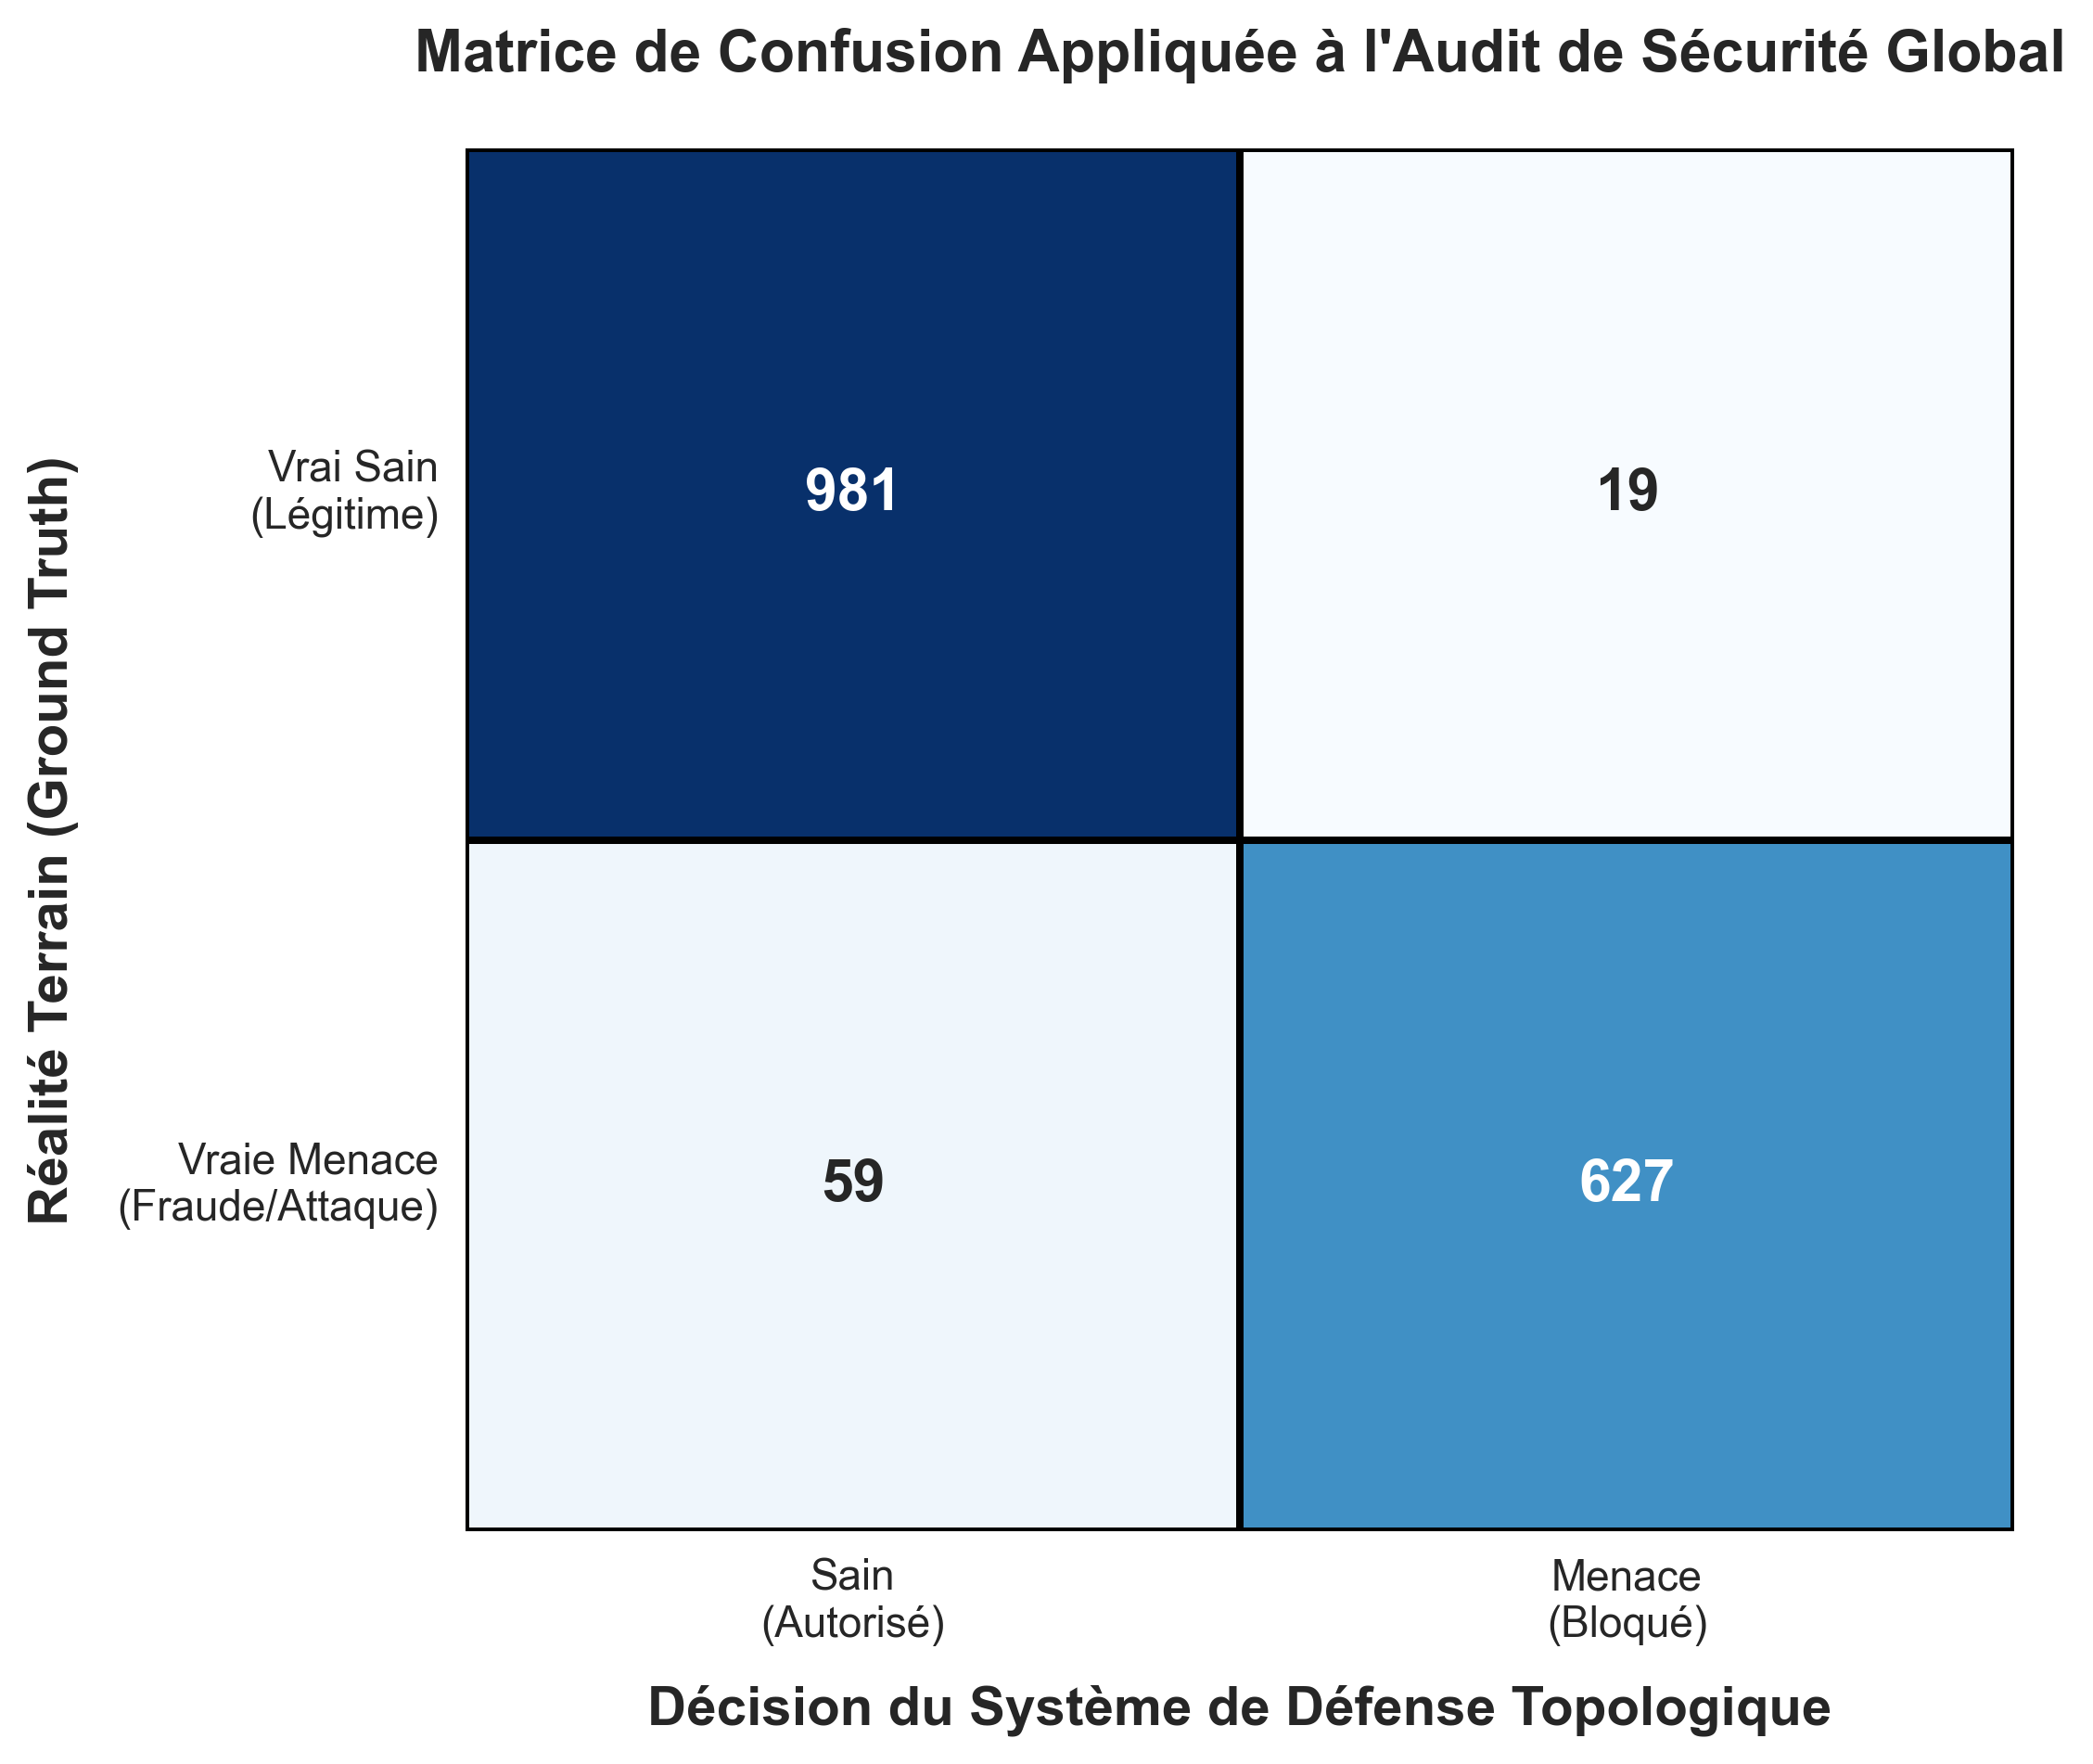

In [ ]:
# BLOC 18
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul dynamique de la matrice de confusion à partir de l'état mémoire
matrice_conf = confusion_matrix(y_vrai_global, y_pred_global)

# 2. Plot de la Heatmap SOTA
plt.figure(figsize=(7.5, 6.5), dpi=300)
ax = sns.heatmap(matrice_conf, annot=True, fmt="d", cmap="Blues", cbar=False,
                 annot_kws={"size": 15, "weight": "bold"}, linewidths=1.5, linecolor='black')

# Personnalisation scientifique des labels
ax.set_xticklabels(['Sain\n(Autorisé)', 'Menace\n(Bloqué)'], fontsize=11)
ax.set_yticklabels(['Vrai Sain\n(Légitime)', 'Vraie Menace\n(Fraude/Attaque)'], fontsize=11, rotation=0)

plt.title("Matrice de Confusion Appliquée à l'Audit de Sécurité Global", fontweight='bold', pad=20)
plt.ylabel('Réalité Terrain (Ground Truth)', fontweight='bold', labelpad=10)
plt.xlabel('Décision du Système de Défense Topologique', fontweight='bold', labelpad=10)
plt.tight_layout()
plt.savefig("3_matrice_confusion_sota.png", dpi=300, bbox_inches='tight')
plt.show()

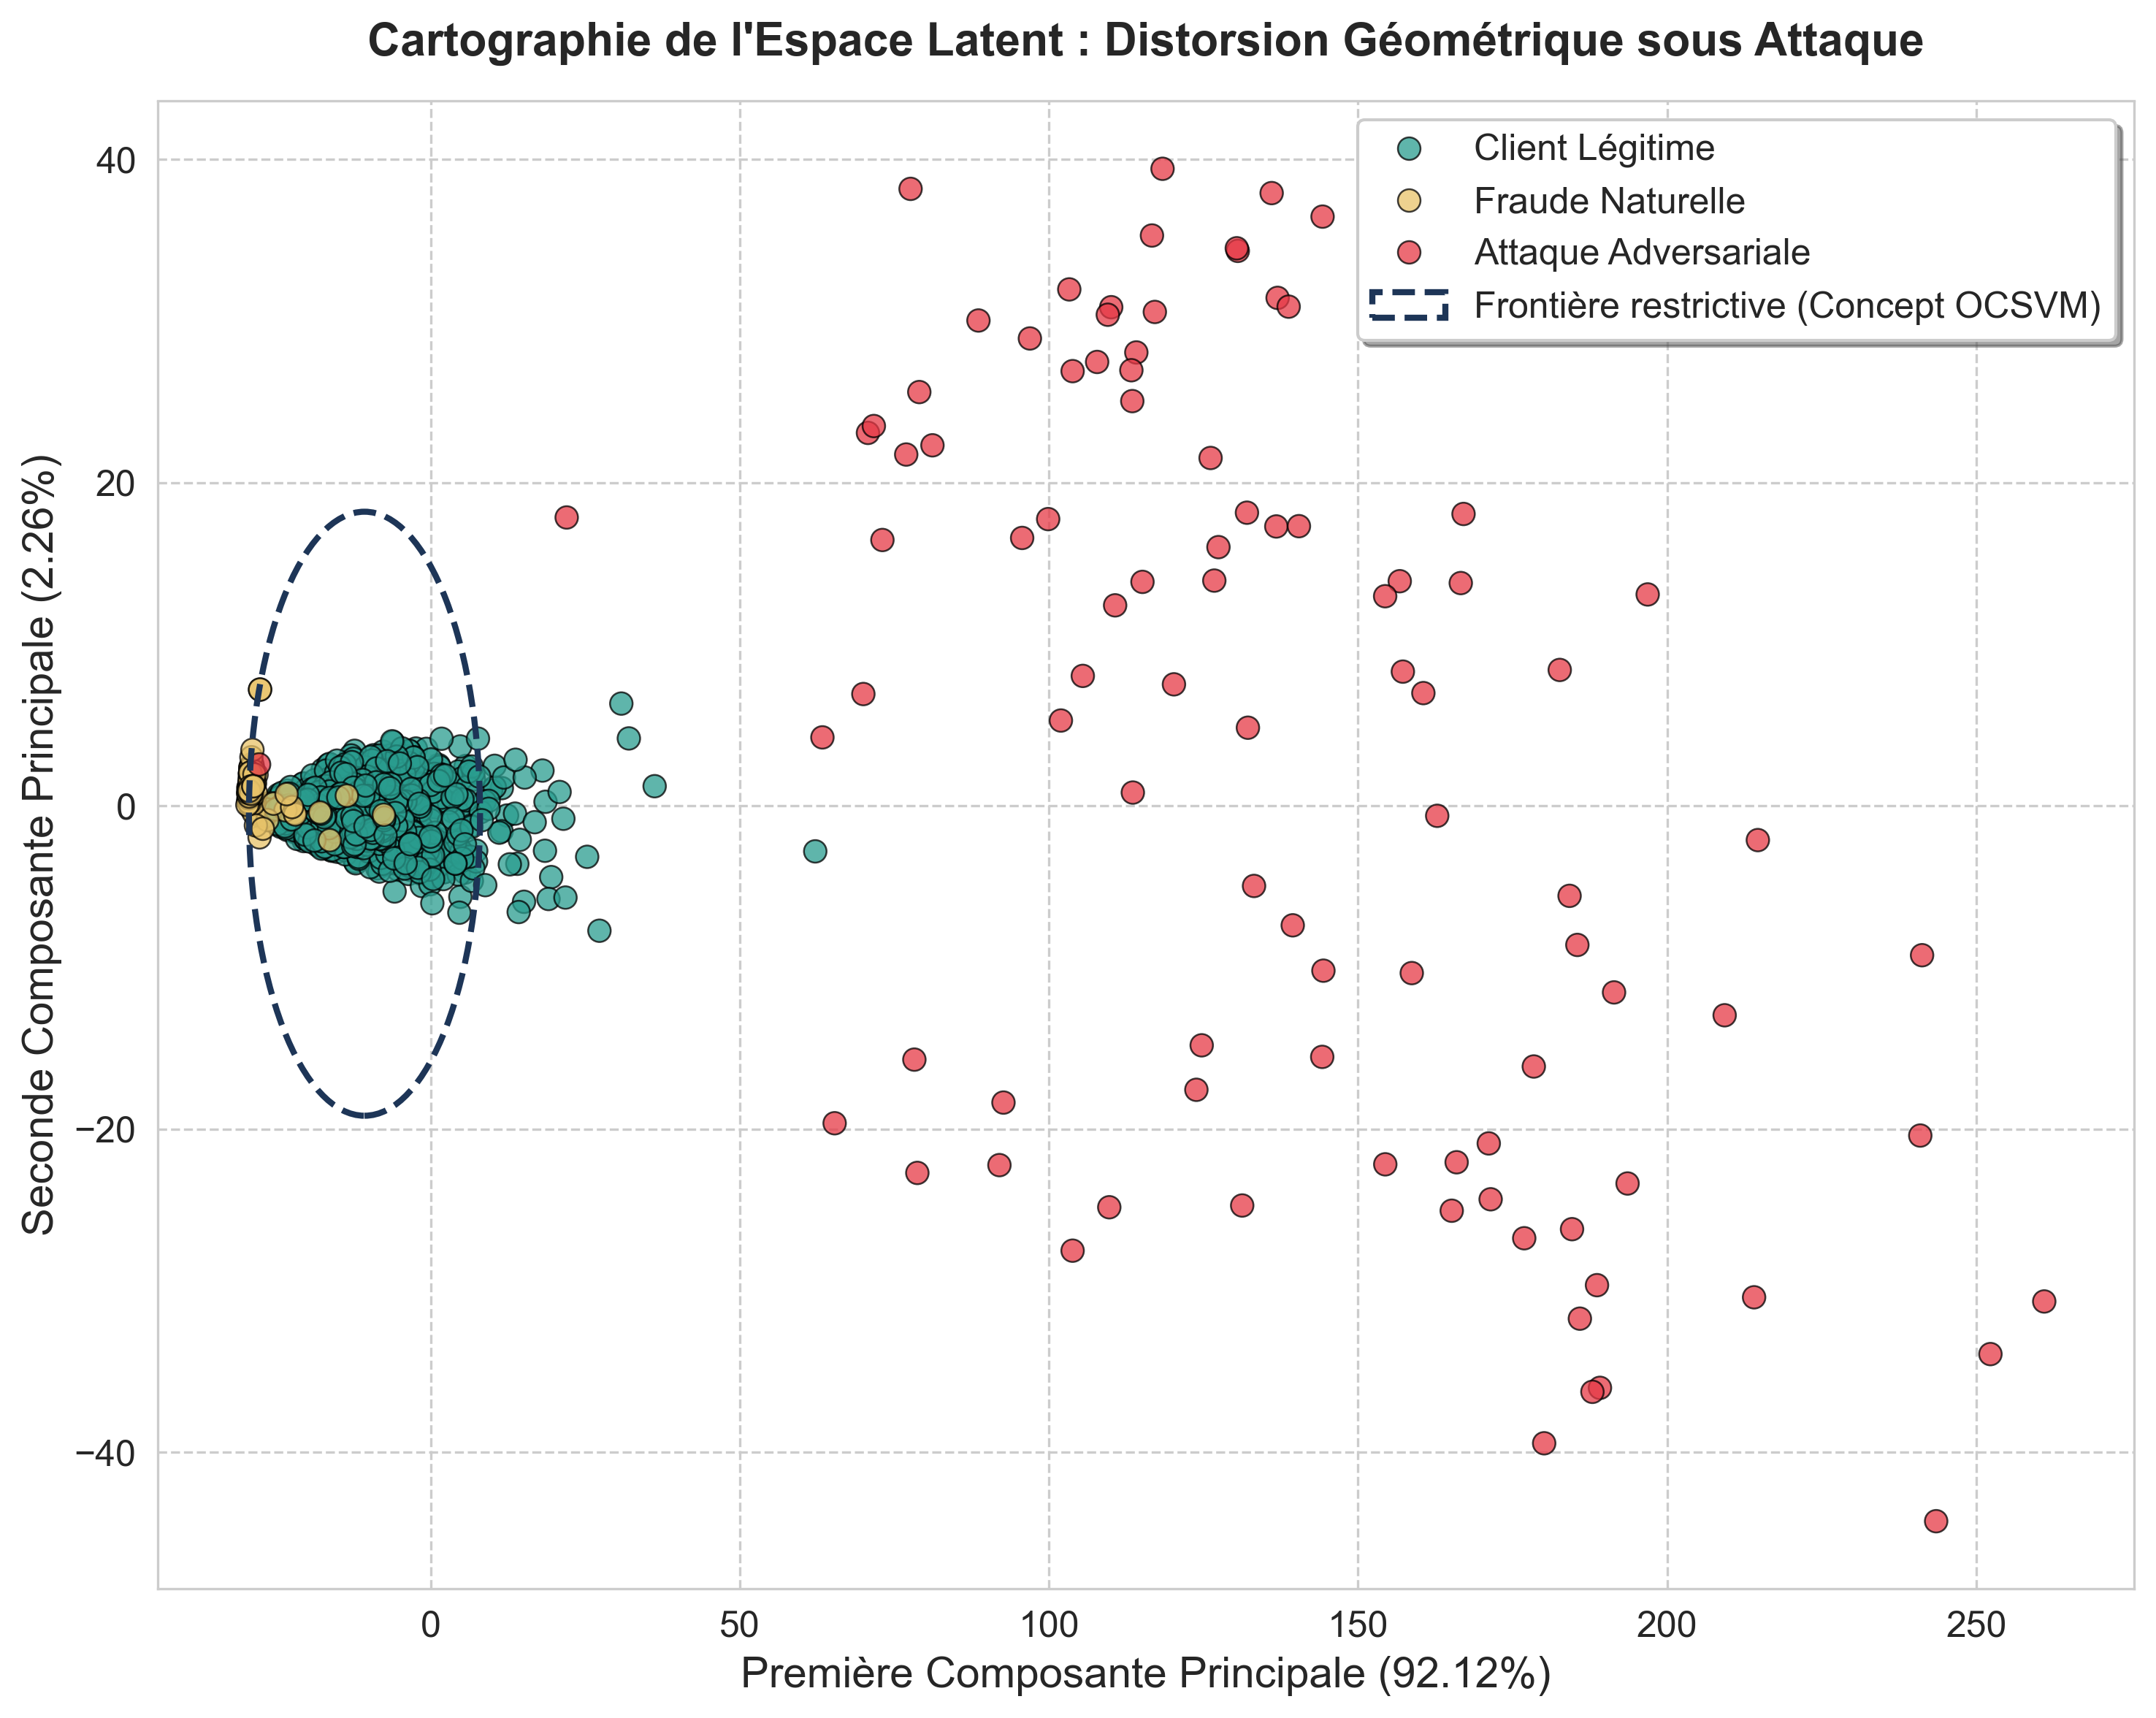

In [ ]:
# BLOC 19
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import torch

# 1. Conversion dynamique et sécurisée des tenseurs d'activations pures
honneta_np = latents_honneta.detach().cpu().numpy() if torch.is_tensor(latents_honneta) else latents_honneta
fraudes_np = latents_fraudes_naturelles.detach().cpu().numpy() if torch.is_tensor(latents_fraudes_naturelles) else latents_fraudes_naturelles
attaques_np = latents_attaques.detach().cpu().numpy() if torch.is_tensor(latents_attaques) else latents_attaques

# Concaténation de l'espace pour l'ajustement PCA
espace_total = np.vstack([honneta_np, fraudes_np, attaques_np])
categories = (['Client Légitime'] * len(honneta_np) + 
              ['Fraude Naturelle'] * len(fraudes_np) + 
              ['Attaque Adversariale'] * len(attaques_np))

# 2. Calcul de la projection 2D
pca_engine = PCA(n_components=2, random_state=42)
coordonnees_2d = pca_engine.fit_transform(espace_total)

# 3. Tracé du nuage de points multi-classes
plt.figure(figsize=(10, 8), dpi=300)
palette_metier = {'Client Légitime': '#2a9d8f', 'Fraude Naturelle': '#e9c46a', 'Attaque Adversariale': '#e63946'}

sns.scatterplot(x=coordonnees_2d[:, 0], y=coordonnees_2d[:, 1], hue=categories, palette=palette_metier,
                s=55, alpha=0.75, edgecolor='black', linewidth=0.6)

# Tracé géométrique indicatif de l'enveloppe de normalité (Hyper-sphère OCSVM)
centre_sain = np.mean(coordonnees_2d[:len(honneta_np)], axis=0)
rayon_sain = np.std(coordonnees_2d[:len(honneta_np), 0]) * 1.95
hyper_sphere = plt.Circle(centre_sain, radius=rayon_sain, color='#1d3557', fill=False, linestyle='--', linewidth=2, label="Frontière restrictive (Concept OCSVM)")
plt.gca().add_patch(hyper_sphere)

plt.title("Cartographie de l'Espace Latent : Distorsion Géométrique sous Attaque", fontweight='bold', pad=15)
plt.xlabel(f"Première Composante Principale ({pca_engine.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"Seconde Composante Principale ({pca_engine.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig("4_frontiere_espace_latent_pca.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\anita\AppData\Local\Temp\ipykernel_24480\1610566671.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Groupe de Test', y='Densité de Connexion (Degré RBF)', data=dataset_boxplot,


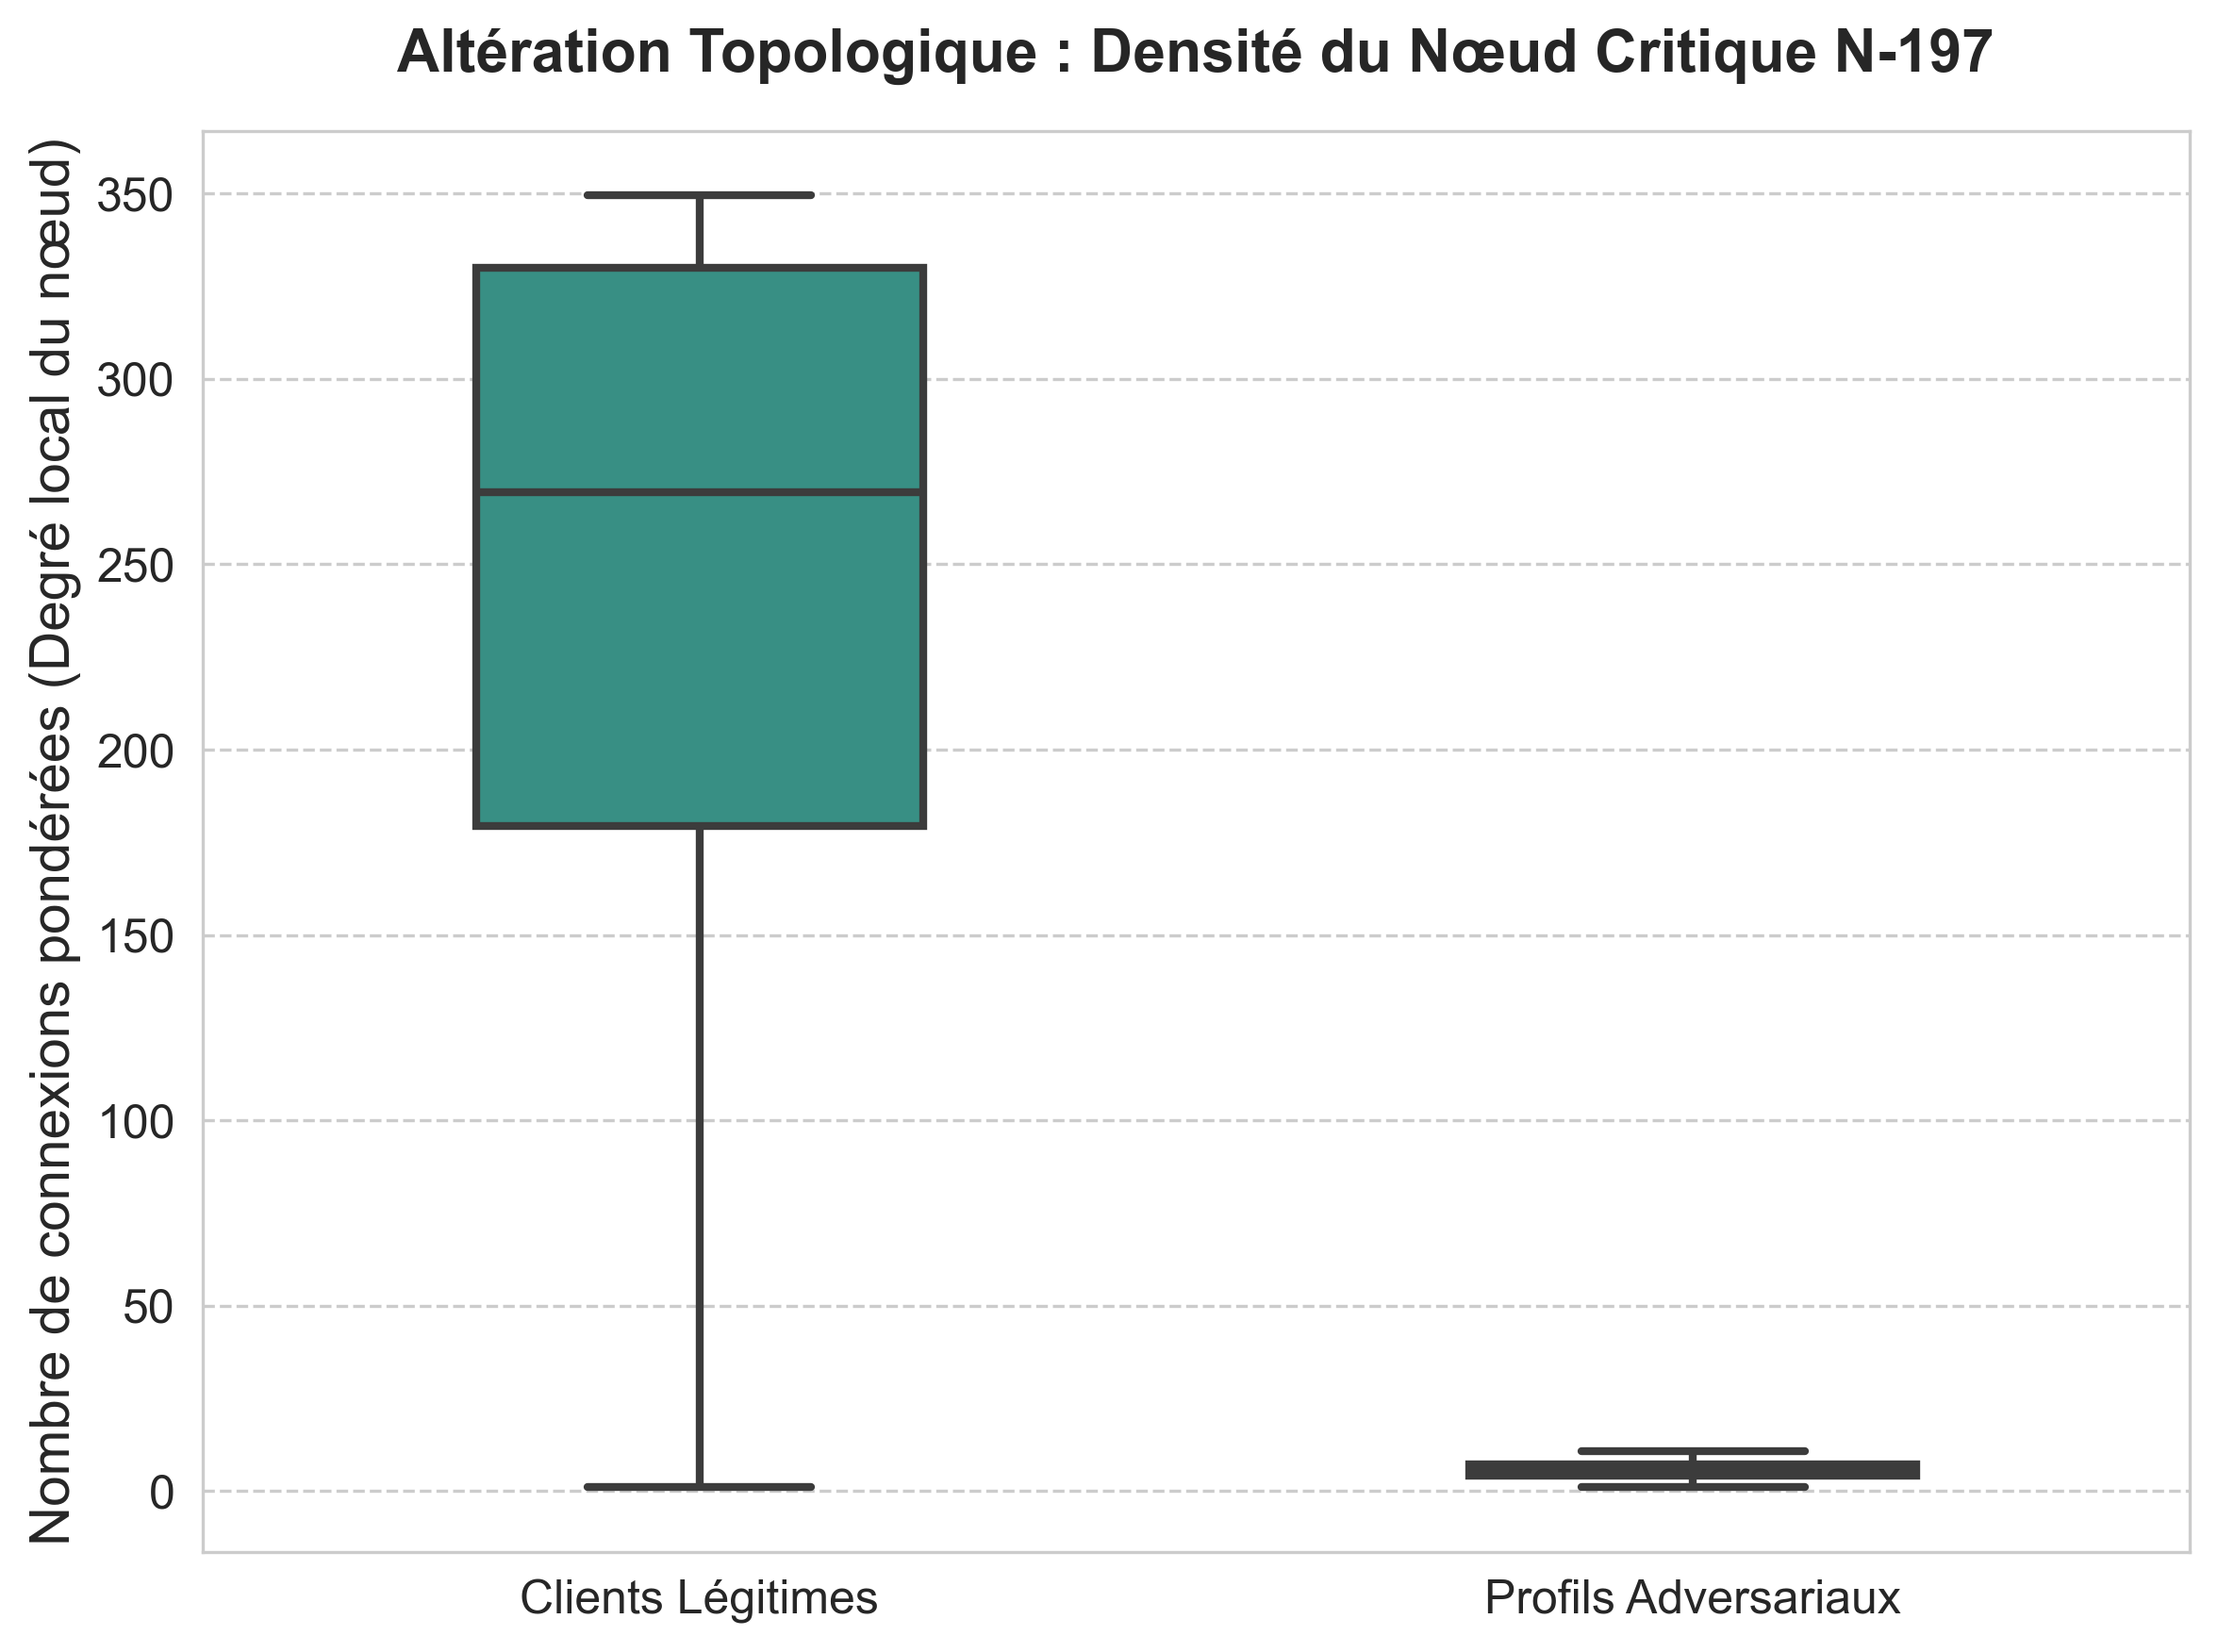

In [ ]:
# BLOC 20
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import numpy as np

# 1. Extraction du neurone le plus critique (Rang 0)
neurone_index = ranked_all_nodes[0].item() if torch.is_tensor(ranked_all_nodes) else ranked_all_nodes[0]
gamma_rbf = 0.5

def extraire_degre_topologique(tenseurs_latents):
    # Isolation de l'unité critique
    activations_unite = tenseurs_latents[:, neurone_index]
    # Calcul de la matrice de similarité locale RBF
    distances = activations_unite.unsqueeze(1) - activations_unite.unsqueeze(0)
    S_rbf = torch.exp(-gamma_rbf * (distances ** 2))
    return S_rbf.sum(dim=1).detach().cpu().numpy()

# Calcul dynamique sur les populations courantes
deg_l_sains = extraire_degre_topologique(latents_honneta)
deg_l_attaques = extraire_degre_topologique(latents_attaques)

# Assemblage du DataFrame d'analyse
dataset_boxplot = pd.DataFrame({
    'Densité de Connexion (Degré RBF)': np.concatenate([deg_l_sains, deg_l_attaques]),
    'Groupe de Test': ['Clients Légitimes'] * len(deg_l_sains) + ['Profils Adversariaux'] * len(deg_l_attaques)
})

# 2. Génération du Boxplot SOTA
plt.figure(figsize=(8, 6), dpi=300)
sns.boxplot(x='Groupe de Test', y='Densité de Connexion (Degré RBF)', data=dataset_boxplot,
            palette={'Clients Légitimes': '#2a9d8f', 'Profils Adversariaux': '#e63946'},
            width=0.45, linewidth=2, fliersize=5)

plt.title(f"Altération Topologique : Densité du Nœud Critique N-{neurone_index}", fontweight='bold', pad=15)
plt.ylabel("Nombre de connexions pondérées (Degré local du nœud)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("5_impact_topologique_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

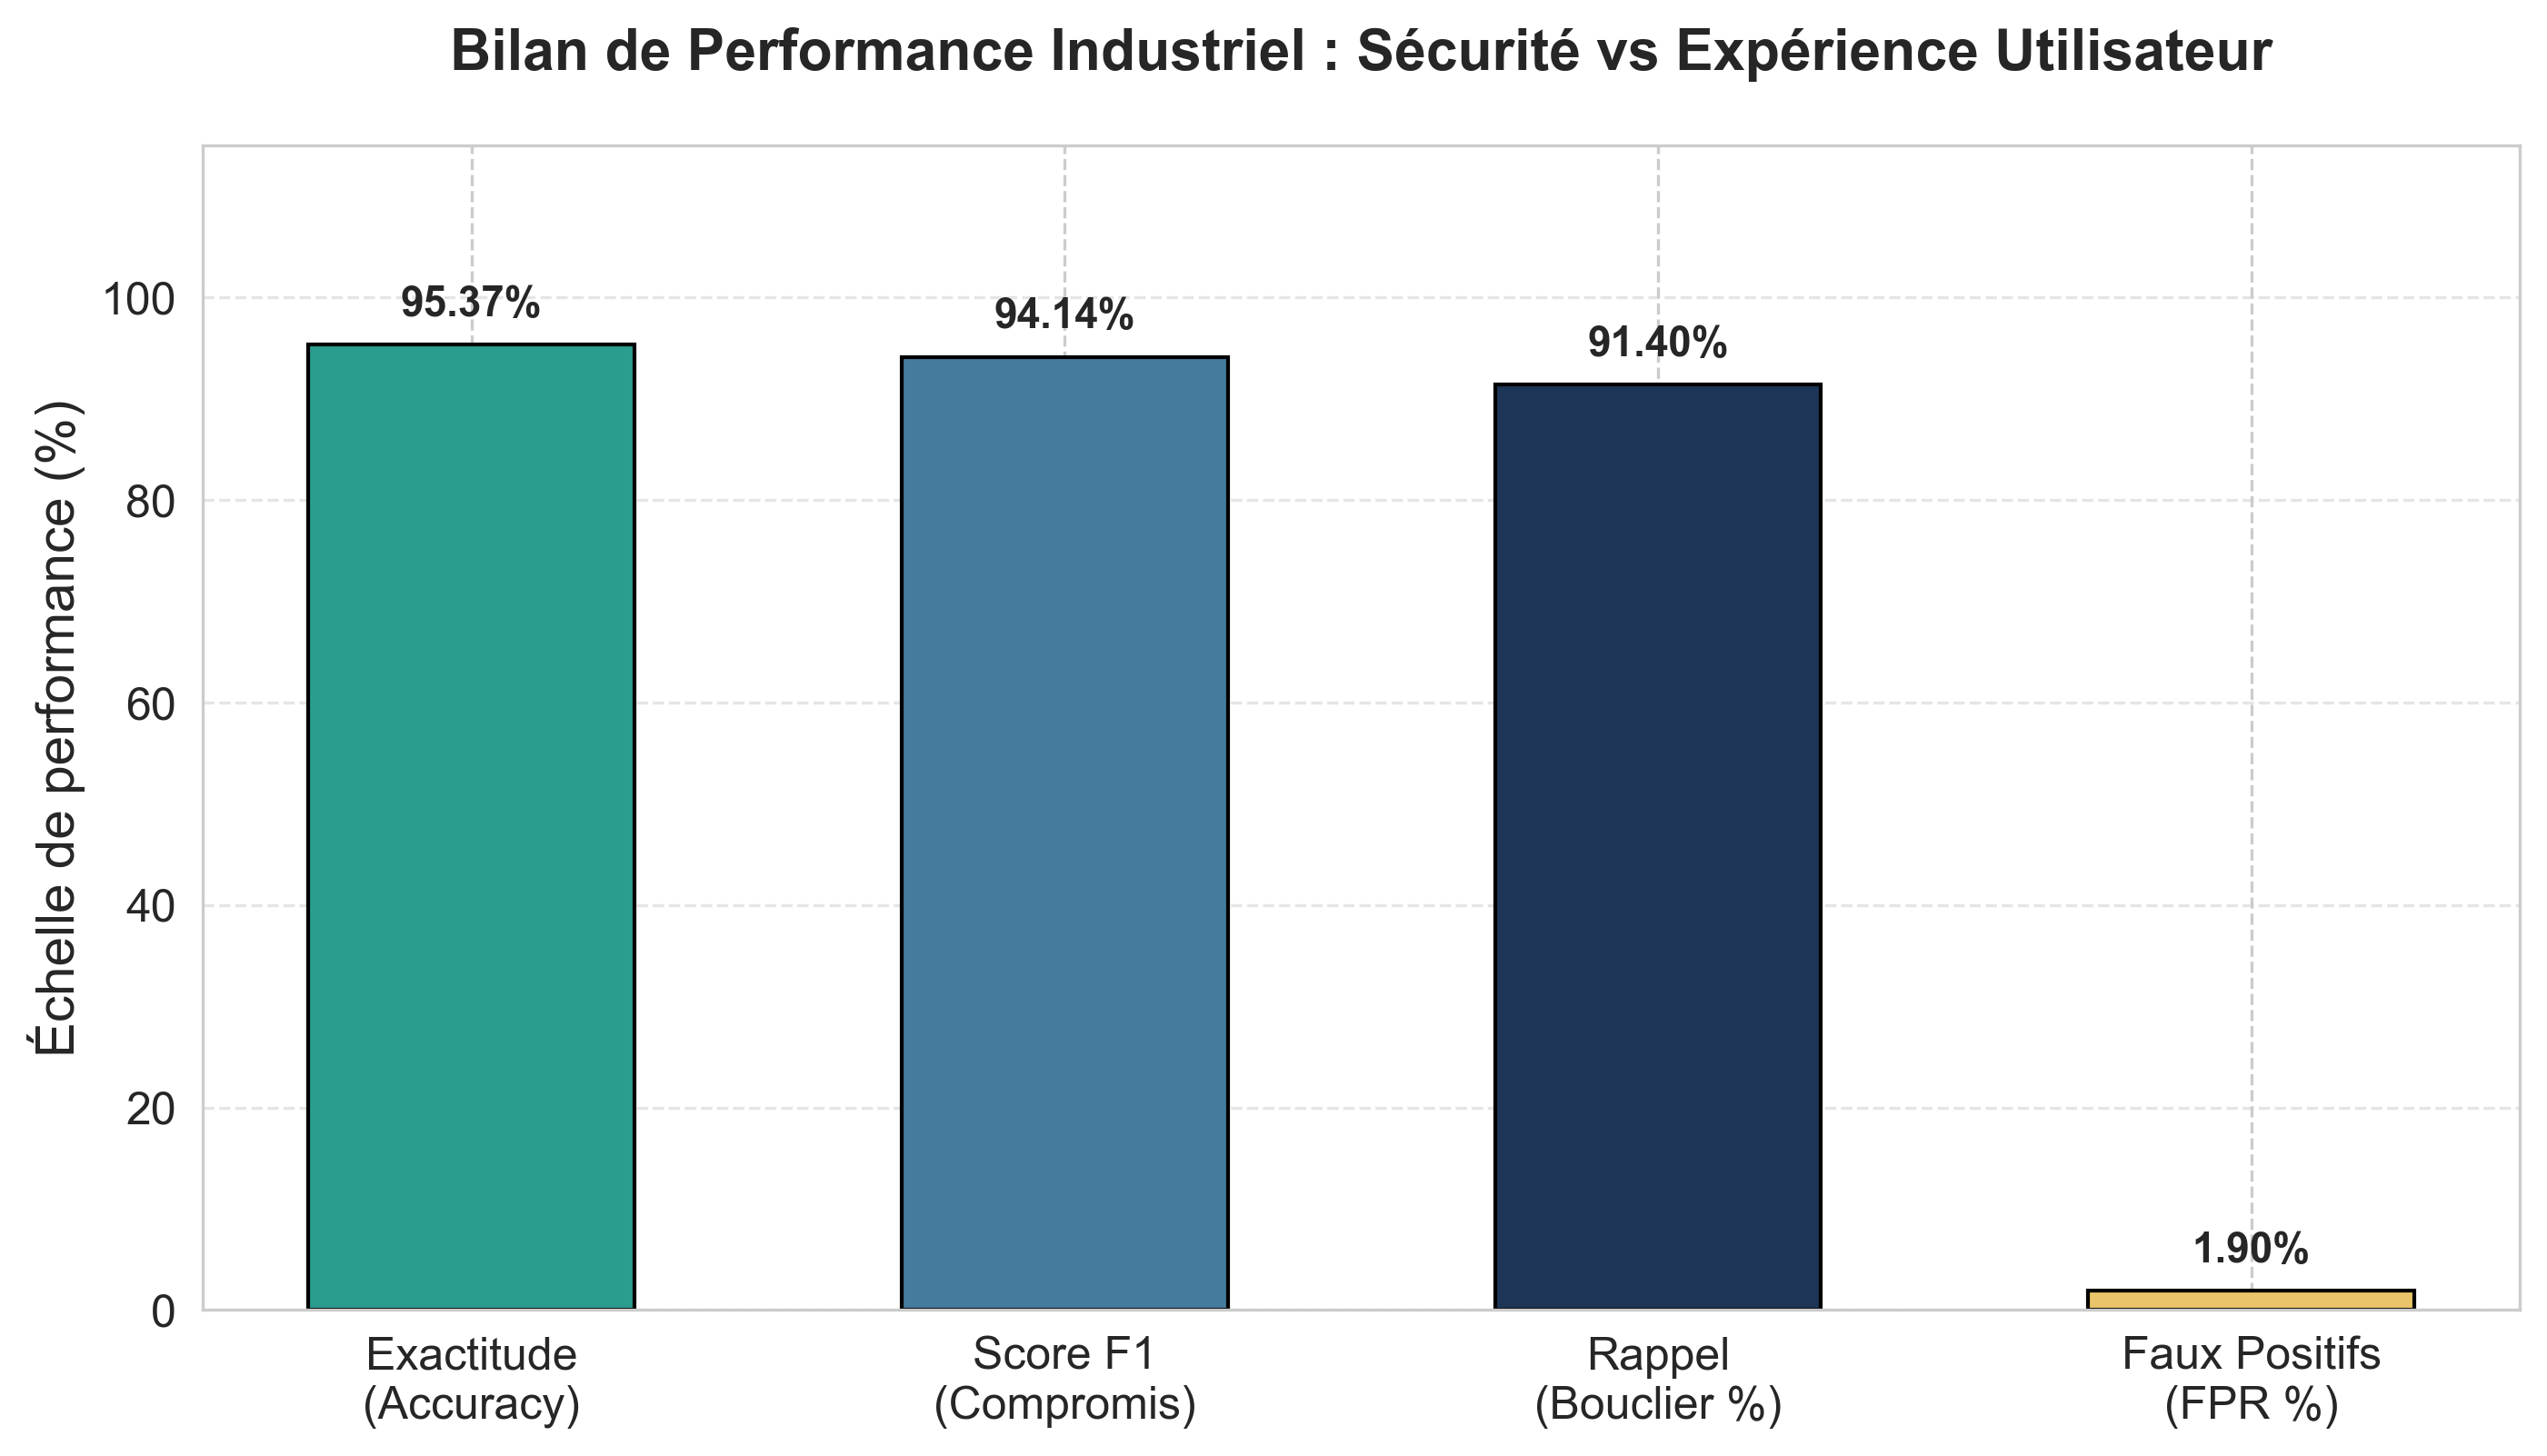

In [ ]:
# BLOC 21
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Calcul en temps réel de toutes les métriques de l'audit courant
val_acc = accuracy_score(y_vrai_global, y_pred_global) * 100
val_f1 = f1_score(y_vrai_global, y_pred_global) * 100
val_rec = recall_score(y_vrai_global, y_pred_global) * 100

tn, fp, fn, tp = confusion_matrix(y_vrai_global, y_pred_global).ravel()
val_fpr = (fp / (fp + tn)) * 100

# Listes pour l'affichage
indicateurs = ['Exactitude\n(Accuracy)', 'Score F1\n(Compromis)', 'Rappel\n(Bouclier %)', 'Faux Positifs\n(FPR %)']
valeurs_metriques = [val_acc, val_f1, val_rec, val_fpr]
nuances_couleurs = ['#2a9d8f', '#457b9d', '#1d3557', '#e9c46a']

# 2. Génération du graphique de synthèse
plt.figure(figsize=(9.5, 5.5), dpi=300)
barres_graph = plt.bar(indicateurs, valeurs_metriques, color=nuances_couleurs, edgecolor='black', linewidth=1, width=0.55)

# Intégration dynamique des scores au-dessus de chaque barre
for b in barres_graph:
    hauteur = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, hauteur + 2, f"{hauteur:.2f}%", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title("Bilan de Performance Industriel : Sécurité vs Expérience Utilisateur", fontweight='bold', pad=20)
plt.ylabel("Échelle de performance (%)")
plt.ylim(0, 115) # Marge supérieure pour accueillir les étiquettes textuelles
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("6_trade_off_performance_bilan.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# BLOC 22
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("==================================================")
print(" 📊 VALEURS EXACTES POUR LA TABLE 1 (BASELINE ANN) ")
print("==================================================")

# On passe le modèle en mode évaluation
model.eval()

with torch.no_grad():
    # On fait prédire le modèle sur l'intégralité du set de validation sain
    outputs = model(X_val_tensor.to(device))
    probs = torch.sigmoid(outputs)
    # Prédiction binaire : > 50% = Fraude
    preds = (probs > 0.5).float().cpu().numpy()
    
y_true = y_val_tensor.cpu().numpy()

# Calcul des métriques avec scikit-learn
acc = accuracy_score(y_true, preds) * 100
prec = precision_score(y_true, preds, zero_division=0) * 100
rec = recall_score(y_true, preds, zero_division=0) * 100
f1 = f1_score(y_true, preds, zero_division=0) * 100

# Extraction du FPR depuis la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
fpr = (fp / (fp + tn)) * 100

print(f"Exactitude Globale (Accuracy) : {acc:.2f} %")
print(f"Précision (Fraudes)           : {prec:.2f} %")
print(f"Rappel (Recall)               : {rec:.2f} %")
print(f"F1-Score                      : {f1:.2f} %")
print(f"Taux de Faux Positifs (FPR)   : {fpr:.2f} %")
print("==================================================")

 📊 VALEURS EXACTES POUR LA TABLE 1 (BASELINE ANN) 
Exactitude Globale (Accuracy) : 99.78 %
Précision (Fraudes)           : 43.07 %
Rappel (Recall)               : 88.78 %
F1-Score                      : 58.00 %
Taux de Faux Positifs (FPR)   : 0.20 %


In [ ]:
# BLOC 23
#Fin du projet

BLOC 24
Analyse de la Frontière de Furtivité : Évaluation des Micro-Perturbations
Si l'évaluation face aux attaques massives démontre la résilience absolue du système de défense, il est scientifiquement crucial d'analyser le comportement du réseau face à des micro-perturbations ($\epsilon \in [0.1, 1.0]$). Cette investigation à haute granularité répond à deux objectifs fondamentaux :
Identifier le point de rupture structurel : L'attaque PGD génère un bruit qui doit surpasser la variance naturelle des poids du réseau. Scanner les epsilons inférieurs à 0.5 permet d'identifier le seuil critique exact à partir duquel la perturbation devient suffisante pour altérer la décision de l'ANN (le décollage de l'ASR).

Valider l'hyper-sensibilité topologique : Face à une attaque de force $\epsilon = 0.2$, le réseau de neurones cible n'est théoriquement pas trompé. Cependant, l'injection du gradient malveillant déforme inévitablement la géométrie de l'espace latent. Soumettre ces micro-attaques au Comité d'Experts permet de vérifier si notre moteur géométrique est capable de détecter "l'intention" du hacker (la distorsion topologique) avant même que son attaque ne soit couronnée de succès, confirmant ainsi la supériorité de l'analyse par graphes sur la simple lecture des probabilités de sortie.


In [ ]:
# BLOC 25
import numpy as np

print("="*65)
print(" 🔬 AUDIT DE HAUTE PRÉCISION : FRONTIÈRE DE FURTIVITÉ ")
print("="*65)
print("Epsilon | ASR Hacker (ANN nu) | Interception par le Comité")
print("-" * 65)

# On cible spécifiquement les epsilons très faibles jusqu'à 1.0
epsilons_furtifs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for eps in epsilons_furtifs:
    # On vérifie que la donnée existe dans le dictionnaire
    if eps in stockage_activations:
        
        # 1. Succès de l'attaque sur l'ANN (Attack Success Rate)
        asr = stockage_activations[eps]['ASR']
        
        # 2. Récupération de l'espace latent déformé
        latents_adv = stockage_activations[eps]['latents_adv']
        
        # 3. Le Comité topologique rend son verdict
        # regle_vote=2 signifie qu'il faut au moins 2 experts sur 3 pour lever l'alerte
        preds_defense = predire_comite(latents_adv, regle_vote=2)
        
        # Calcul du pourcentage bloqué
        taux_interception = (np.sum(preds_defense) / len(preds_defense)) * 100
        
        # Affichage formaté
        print(f"  {eps:.1f}   |       {asr:5.2f} %       |          {taux_interception:6.2f} %")
        
    else:
        print(f"  {eps:.1f}   | Non calculé dans le dictionnaire initial.")

print("="*65)

 🔬 AUDIT DE HAUTE PRÉCISION : FRONTIÈRE DE FURTIVITÉ 
Epsilon | ASR Hacker (ANN nu) | Interception par le Comité
-----------------------------------------------------------------
  0.1   |        2.30 %       |           87.76 %
  0.2   |        5.75 %       |           87.76 %
  0.3   |       19.54 %       |           85.71 %
  0.4   |       26.44 %       |           81.63 %
  0.5   |       37.93 %       |           81.63 %
  0.6   |       44.83 %       |           81.63 %
  0.7   |       56.32 %       |           76.53 %
  0.8   |       59.77 %       |           74.49 %
  0.9   |       64.37 %       |           77.55 %
  1.0   |       65.52 %       |           78.57 %
